<a href="https://colab.research.google.com/github/denisovich14072006-afk/linear-regression-task/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22Untitled2_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Новый раздел

/tmp/ipykernel_406/3602992315.py:25: RuntimeWarning: overflow encountered in matmul
  w -= lr * 2 * X.T @ (X @ w - y)
/tmp/ipykernel_406/3602992315.py:25: RuntimeWarning: invalid value encountered in matmul
  w -= lr * 2 * X.T @ (X @ w - y)


ValueError: Input contains NaN.

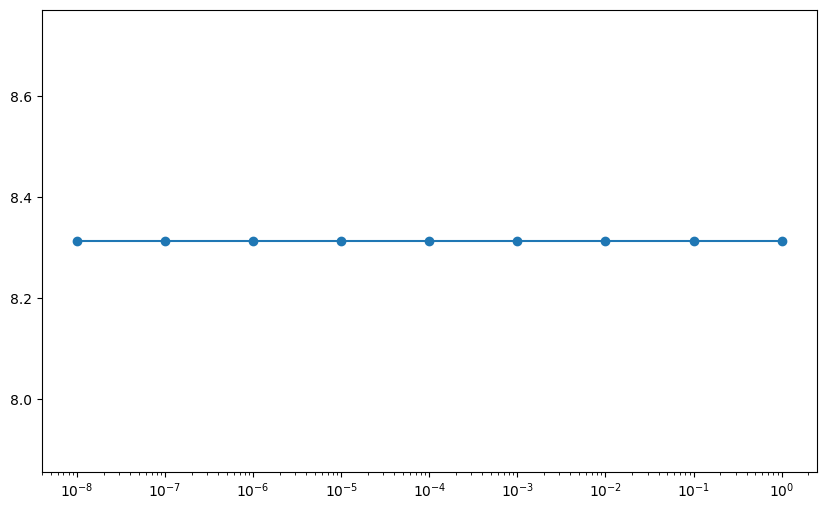

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline

# ---------- Загрузка данных ----------
df = pd.read_csv('data.csv')
X = df[['x']].values
y = df['y'].values

# ---------- Реализации методов ----------
def normal_equation(X, y, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def gradient_descent(X, y, lr=0.01, epochs=1000, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        w -= lr * 2 * X.T @ (X @ w - y)
    return w

def sgd(X, y, lr=0.01, epochs=100, batch_size=32, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            w -= lr * 2 * Xb.T @ (Xb @ w - yb)
    return w

# ---------- Константы для независимых методов ----------
Xwb = np.hstack([np.ones((X.shape[0], 1)), X])
w_ne = normal_equation(X, y)
mse_ne = mean_squared_error(y, Xwb @ w_ne)
lr_sk = LinearRegression().fit(X, y)
mse_lr_sk = mean_squared_error(y, lr_sk.predict(X))

# ---------- Универсальная функция оценки ----------
def compute_mse(method, lr=None, epochs=None, batch_size=None):
    np.random.seed(42)
    if method == 'ne':
        return mse_ne
    if method == 'gd':
        w = gradient_descent(X, y, lr=lr, epochs=epochs)
        return mean_squared_error(y, Xwb @ w)
    if method == 'sgd':
        w = sgd(X, y, lr=lr, epochs=epochs, batch_size=batch_size)
        return mean_squared_error(y, Xwb @ w)
    if method == 'lr_sk':
        return mse_lr_sk
    if method == 'sgd_sk':
        sgd_sk = SGDRegressor(fit_intercept=True, max_iter=epochs, eta0=lr,
                              learning_rate='constant', penalty=None, tol=None,
                              batch_size=batch_size, random_state=42)
        sgd_sk.fit(X, y)
        return mean_squared_error(y, sgd_sk.predict(X))
    raise ValueError('Unknown method')

# ---------- Диапазоны параметров ----------
lr_range = np.logspace(-8, 0, 9)
epochs_range = [2, 20, 200, 2000, 20000]
batch_range = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

DEFAULT_LR = 0.01
DEFAULT_EPOCHS = 1000
DEFAULT_BATCH = 32

methods = [
    ('ne', 'Normal Equation'),
    ('gd', 'GD'),
    ('sgd', 'SGD'),
    ('lr_sk', 'sklearn LR'),
    ('sgd_sk', 'sklearn SGD')
]

# ---------- График 1: learning rate ----------
plt.figure(figsize=(10, 6))
for method, label in methods:
    mses = [compute_mse(method, lr=lr, epochs=DEFAULT_EPOCHS, batch_size=DEFAULT_BATCH) for lr in lr_range]
    plt.semilogx(lr_range, mses, marker='o', label=label)
plt.xlabel('Learning rate')
plt.ylabel('MSE')
plt.title('Зависимость MSE от learning rate')
plt.legend()
plt.grid(True)
plt.show()

# ---------- График 2: эпохи ----------
plt.figure(figsize=(10, 6))
for method, label in methods:
    mses = [compute_mse(method, lr=DEFAULT_LR, epochs=e, batch_size=DEFAULT_BATCH) for e in epochs_range]
    plt.semilogx(epochs_range, mses, marker='o', label=label)
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Зависимость MSE от количества эпох')
plt.legend()
plt.grid(True)
plt.show()

# ---------- График 3: размер батча ----------
plt.figure(figsize=(10, 6))
for method, label in methods:
    mses = [compute_mse(method, lr=DEFAULT_LR, epochs=DEFAULT_EPOCHS, batch_size=b) for b in batch_range]
    plt.semilogx(batch_range, mses, marker='o', label=label)
plt.xlabel('Batch size')
plt.ylabel('MSE')
plt.title('Зависимость MSE от размера батча')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_406/2801481722.py:26: RuntimeWarning: overflow encountered in matmul
  w -= lr * 2 * X.T @ (X @ w - y)
/tmp/ipykernel_406/2801481722.py:26: RuntimeWarning: invalid value encountered in matmul
  w -= lr * 2 * X.T @ (X @ w - y)
/tmp/ipykernel_406/2801481722.py:39: RuntimeWarning: overflow encountered in matmul
  w -= lr * 2 * Xb.T @ (Xb @ w - yb)
/tmp/ipykernel_406/2801481722.py:39: RuntimeWarning: invalid value encountered in subtract
  w -= lr * 2 * Xb.T @ (Xb @ w - yb)
/tmp/ipykernel_406/2801481722.py:39: RuntimeWarning: invalid value encountered in matmul
  w -= lr * 2 * Xb.T @ (Xb @ w - yb)


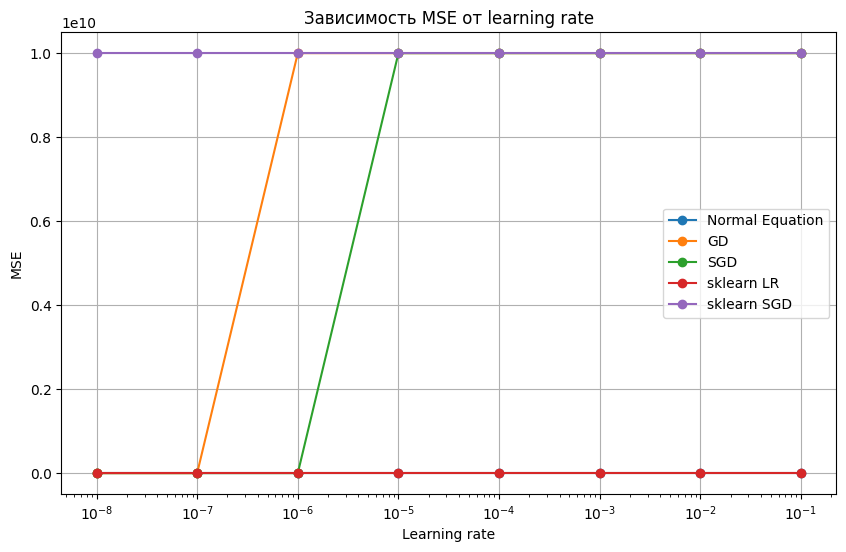

/tmp/ipykernel_406/2801481722.py:26: RuntimeWarning: overflow encountered in matmul
  w -= lr * 2 * X.T @ (X @ w - y)
/tmp/ipykernel_406/2801481722.py:26: RuntimeWarning: invalid value encountered in matmul
  w -= lr * 2 * X.T @ (X @ w - y)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/tmp/ipykernel_406/2801481722.py:39: RuntimeWarning: overflow encountered in matmul
  w -= lr * 2 * Xb.T @ (Xb @ w - yb)
/tmp/ipykernel_406/2801481722.py:39: RuntimeWarning: invalid value encountered in matmul
  w -= lr * 2 * Xb.T @ (Xb @ w - yb)


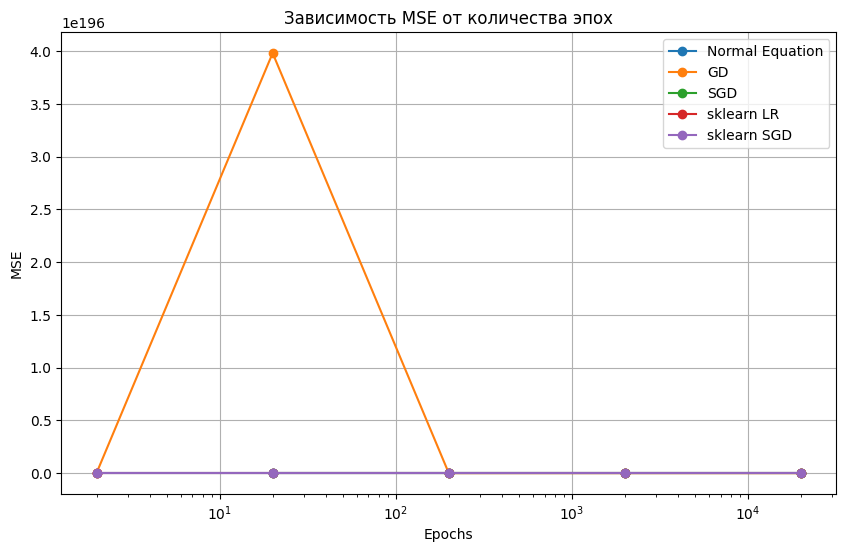

/tmp/ipykernel_406/2801481722.py:26: RuntimeWarning: overflow encountered in matmul
  w -= lr * 2 * X.T @ (X @ w - y)
/tmp/ipykernel_406/2801481722.py:26: RuntimeWarning: invalid value encountered in matmul
  w -= lr * 2 * X.T @ (X @ w - y)
/tmp/ipykernel_406/2801481722.py:39: RuntimeWarning: invalid value encountered in subtract
  w -= lr * 2 * Xb.T @ (Xb @ w - yb)


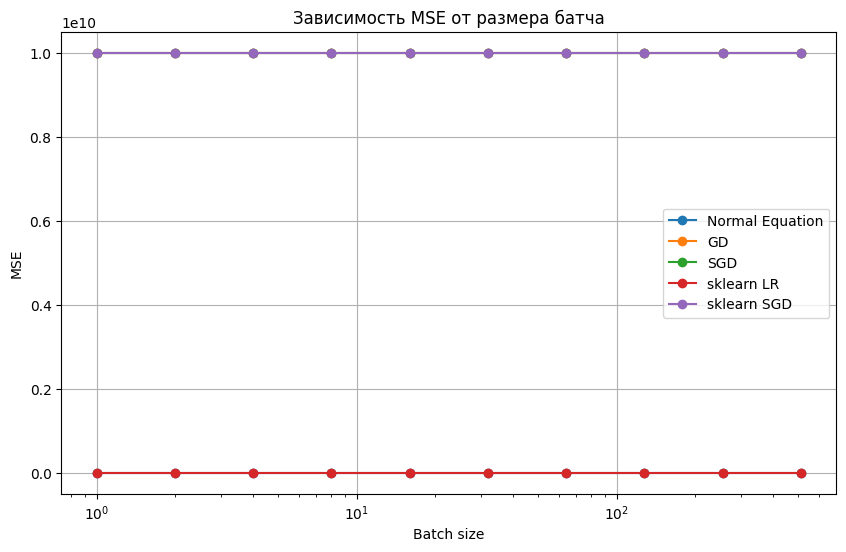

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline

# ---------- Загрузка данных ----------
# Загрузите ваш CSV в Colab (например, через files.upload())
df = pd.read_csv('data.csv')
X = df[['x']].values
y = df['y'].values

# ---------- Реализации методов ----------
def normal_equation(X, y, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def gradient_descent(X, y, lr=0.01, epochs=1000, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        w -= lr * 2 * X.T @ (X @ w - y)
    return w

def sgd(X, y, lr=0.01, epochs=100, batch_size=32, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            w -= lr * 2 * Xb.T @ (Xb @ w - yb)
    return w

# ---------- Константы ----------
Xwb = np.hstack([np.ones((X.shape[0], 1)), X])
w_ne = normal_equation(X, y)
mse_ne = mean_squared_error(y, Xwb @ w_ne)
lr_sk = LinearRegression().fit(X, y)
mse_lr_sk = mean_squared_error(y, lr_sk.predict(X))

# ---------- Универсальная функция с защитой от NaN ----------
BIG_MSE = 1e10  # значение, возвращаемое при расходимости

def compute_mse(method, lr=None, epochs=None, batch_size=None):
    np.random.seed(42)
    try:
        if method == 'ne':
            return mse_ne
        elif method == 'gd':
            w = gradient_descent(X, y, lr=lr, epochs=epochs)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return BIG_MSE
            return mean_squared_error(y, Xwb @ w)
        elif method == 'sgd':
            w = sgd(X, y, lr=lr, epochs=epochs, batch_size=batch_size)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return BIG_MSE
            return mean_squared_error(y, Xwb @ w)
        elif method == 'lr_sk':
            return mse_lr_sk
        elif method == 'sgd_sk':
            sgd_sk = SGDRegressor(
                fit_intercept=True,
                max_iter=epochs,
                eta0=lr,
                learning_rate='constant',
                penalty=None,
                tol=None,
                batch_size=batch_size,
                random_state=42
            )
            sgd_sk.fit(X, y)
            y_pred = sgd_sk.predict(X)
            if np.any(np.isnan(y_pred)):
                return BIG_MSE
            return mean_squared_error(y, y_pred)
        else:
            raise ValueError('Unknown method')
    except Exception:
        return BIG_MSE  # при любой ошибке (например, взрыв градиента)

# ---------- Диапазоны гиперпараметров ----------
# learning rate теперь ограничен 0.1, чтобы избежать расходимости
lr_range = np.logspace(-8, -1, 8)      # от 1e-8 до 0.1
epochs_range = [2, 20, 200, 2000, 20000]
batch_range = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

DEFAULT_LR = 0.01
DEFAULT_EPOCHS = 1000
DEFAULT_BATCH = 32

methods = [
    ('ne', 'Normal Equation'),
    ('gd', 'GD'),
    ('sgd', 'SGD'),
    ('lr_sk', 'sklearn LR'),
    ('sgd_sk', 'sklearn SGD')
]

# ---------- График 1: влияние learning rate ----------
plt.figure(figsize=(10, 6))
for method, label in methods:
    mses = [compute_mse(method, lr=lr, epochs=DEFAULT_EPOCHS, batch_size=DEFAULT_BATCH) for lr in lr_range]
    plt.semilogx(lr_range, mses, marker='o', label=label)
plt.xlabel('Learning rate')
plt.ylabel('MSE')
plt.title('Зависимость MSE от learning rate')
plt.legend()
plt.grid(True)
plt.show()

# ---------- График 2: влияние числа эпох ----------
plt.figure(figsize=(10, 6))
for method, label in methods:
    mses = [compute_mse(method, lr=DEFAULT_LR, epochs=e, batch_size=DEFAULT_BATCH) for e in epochs_range]
    plt.semilogx(epochs_range, mses, marker='o', label=label)
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Зависимость MSE от количества эпох')
plt.legend()
plt.grid(True)
plt.show()

# ---------- График 3: влияние размера батча ----------
plt.figure(figsize=(10, 6))
for method, label in methods:
    mses = [compute_mse(method, lr=DEFAULT_LR, epochs=DEFAULT_EPOCHS, batch_size=b) for b in batch_range]
    plt.semilogx(batch_range, mses, marker='o', label=label)
plt.xlabel('Batch size')
plt.ylabel('MSE')
plt.title('Зависимость MSE от размера батча')
plt.legend()
plt.grid(True)
plt.show()

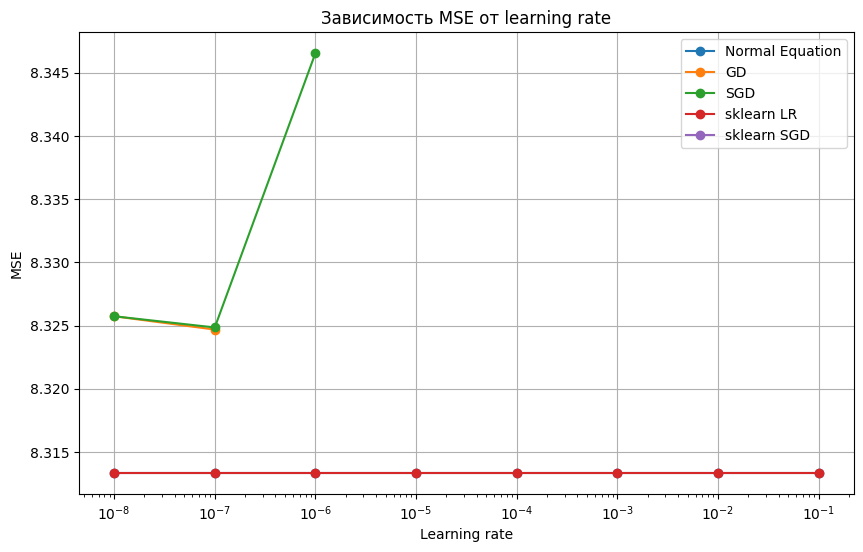

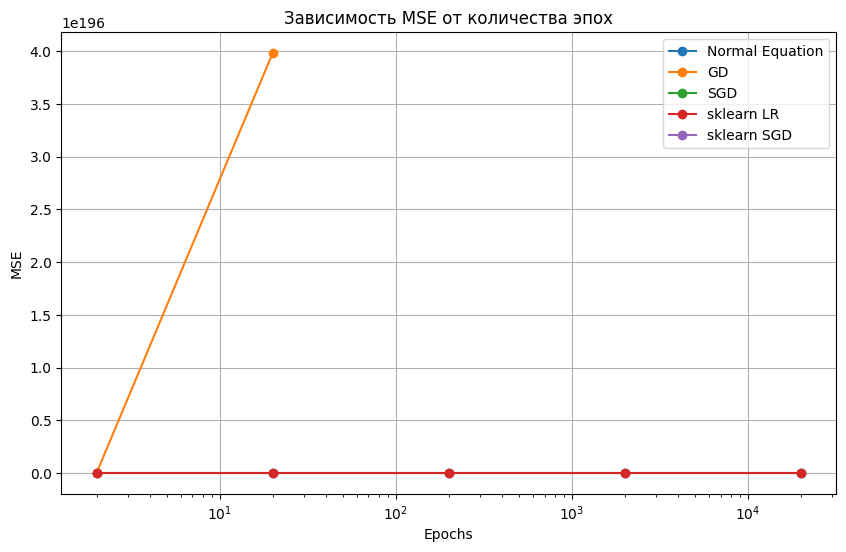

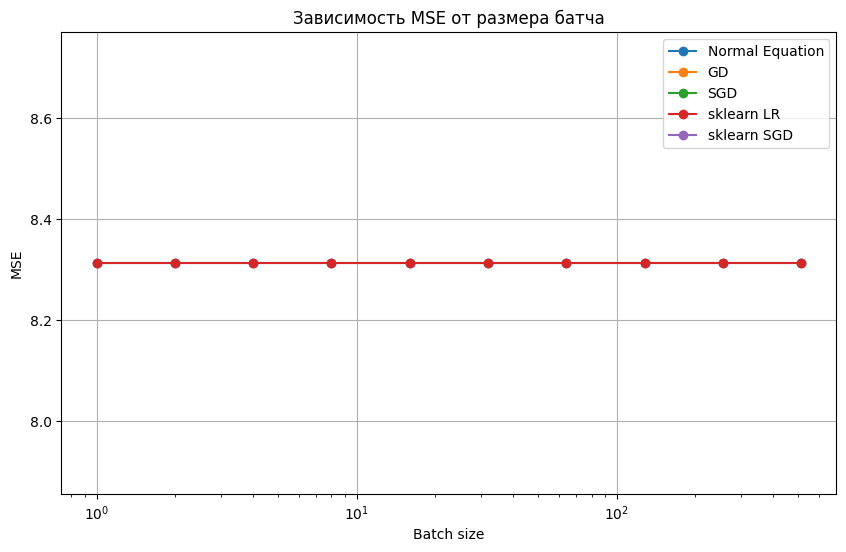

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline

# Загрузка данных
df = pd.read_csv('data.csv')
X = df[['x']].values
y = df['y'].values

# Реализации методов
def normal_equation(X, y, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def gradient_descent(X, y, lr=0.01, epochs=1000, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        w -= lr * 2 * X.T @ (X @ w - y)
    return w

def sgd(X, y, lr=0.01, epochs=100, batch_size=32, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            w -= lr * 2 * Xb.T @ (Xb @ w - yb)
    return w

# Константы
Xwb = np.hstack([np.ones((X.shape[0], 1)), X])
w_ne = normal_equation(X, y)
mse_ne = mean_squared_error(y, Xwb @ w_ne)
lr_sk = LinearRegression().fit(X, y)
mse_lr_sk = mean_squared_error(y, lr_sk.predict(X))

# Функция оценки с возвратом NaN при расходимости
def compute_mse(method, lr=None, epochs=None, batch_size=None):
    np.random.seed(42)
    try:
        if method == 'ne':
            return mse_ne
        elif method == 'gd':
            w = gradient_descent(X, y, lr=lr, epochs=epochs)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'sgd':
            w = sgd(X, y, lr=lr, epochs=epochs, batch_size=batch_size)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'lr_sk':
            return mse_lr_sk
        elif method == 'sgd_sk':
            sgd_sk = SGDRegressor(
                fit_intercept=True,
                max_iter=epochs,
                eta0=lr,
                learning_rate='constant',
                penalty=None,
                tol=None,
                batch_size=batch_size,
                random_state=42
            )
            sgd_sk.fit(X, y)
            y_pred = sgd_sk.predict(X)
            if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
                return np.nan
            return mean_squared_error(y, y_pred)
        else:
            raise ValueError('Unknown method')
    except Exception:
        return np.nan

# Диапазоны гиперпараметров (learning rate до 0.1, как раньше, но можно и до 0.5)
lr_range = np.logspace(-8, -1, 8)   # 1e-8 ... 0.1
epochs_range = [2, 20, 200, 2000, 20000]
batch_range = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

DEFAULT_LR = 0.01
DEFAULT_EPOCHS = 1000
DEFAULT_BATCH = 32

methods = [
    ('ne', 'Normal Equation'),
    ('gd', 'GD'),
    ('sgd', 'SGD'),
    ('lr_sk', 'sklearn LR'),
    ('sgd_sk', 'sklearn SGD')
]

# График 1: learning rate
plt.figure(figsize=(10, 6))
for method, label in methods:
    mses = [compute_mse(method, lr=lr, epochs=DEFAULT_EPOCHS, batch_size=DEFAULT_BATCH) for lr in lr_range]
    plt.semilogx(lr_range, mses, marker='o', label=label)
plt.xlabel('Learning rate')
plt.ylabel('MSE')
plt.title('Зависимость MSE от learning rate')
plt.legend()
plt.grid(True)
plt.show()

# График 2: эпохи
plt.figure(figsize=(10, 6))
for method, label in methods:
    mses = [compute_mse(method, lr=DEFAULT_LR, epochs=e, batch_size=DEFAULT_BATCH) for e in epochs_range]
    plt.semilogx(epochs_range, mses, marker='o', label=label)
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Зависимость MSE от количества эпох')
plt.legend()
plt.grid(True)
plt.show()

# График 3: размер батча
plt.figure(figsize=(10, 6))
for method, label in methods:
    mses = [compute_mse(method, lr=DEFAULT_LR, epochs=DEFAULT_EPOCHS, batch_size=b) for b in batch_range]
    plt.semilogx(batch_range, mses, marker='o', label=label)
plt.xlabel('Batch size')
plt.ylabel('MSE')
plt.title('Зависимость MSE от размера батча')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


Загрузите файл data.csv:


Saving data.csv to data (1).csv
Данные загружены. X shape: (999, 1), y shape: (999,)

ГРАФИК 1: Зависимость MSE от learning rate


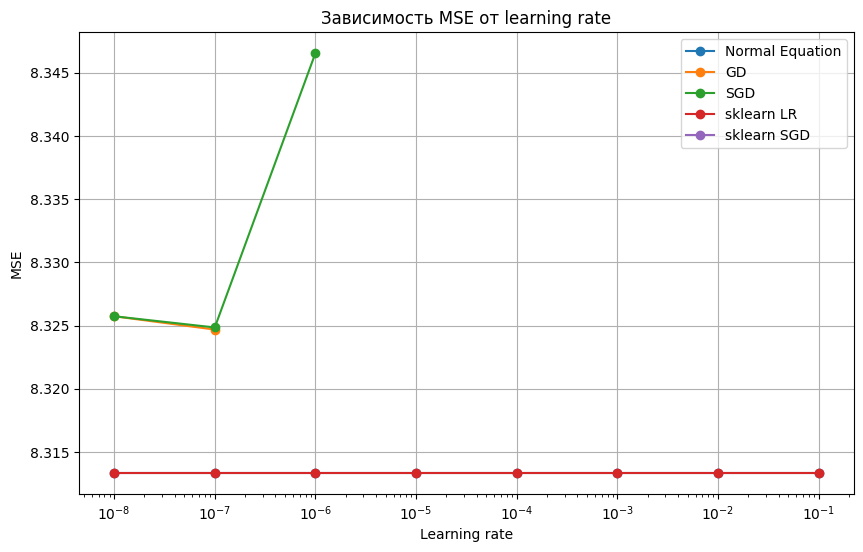


Таблица значений MSE для Зависимость MSE от learning rate:
               Normal Equation        GD       SGD  sklearn LR  sklearn SGD
Learning rate                                                              
1.000000e-08          8.313329  8.325737  8.325737    8.313329          NaN
1.000000e-07          8.313329  8.324683  8.324850    8.313329          NaN
1.000000e-06          8.313329       NaN  8.346550    8.313329          NaN
1.000000e-05          8.313329       NaN       NaN    8.313329          NaN
1.000000e-04          8.313329       NaN       NaN    8.313329          NaN
1.000000e-03          8.313329       NaN       NaN    8.313329          NaN
1.000000e-02          8.313329       NaN       NaN    8.313329          NaN
1.000000e-01          8.313329       NaN       NaN    8.313329          NaN

ГРАФИК 2: Зависимость MSE от количества эпох


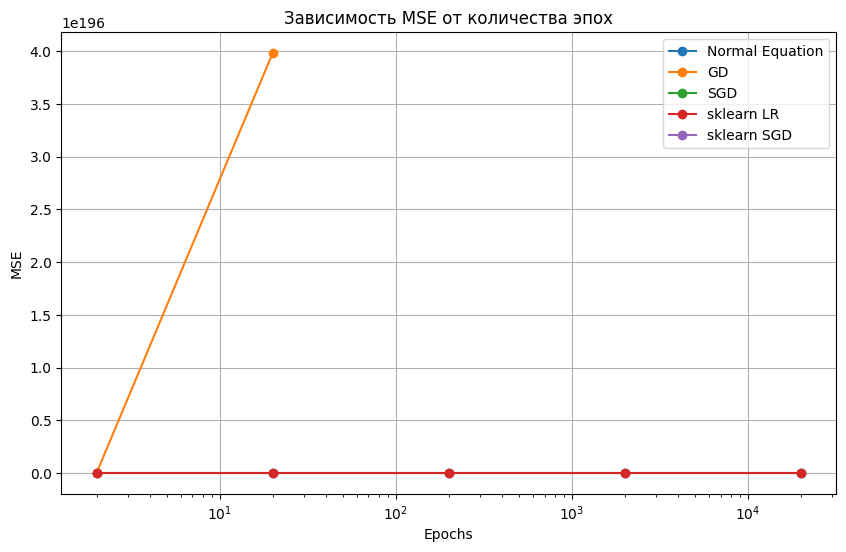


Таблица значений MSE для Зависимость MSE от количества эпох:
        Normal Equation             GD  SGD  sklearn LR  sklearn SGD
Epochs                                                              
2              8.313329   6.835259e+22  inf    8.313329          NaN
20             8.313329  3.980530e+196  NaN    8.313329          NaN
200            8.313329            NaN  NaN    8.313329          NaN
2000           8.313329            NaN  NaN    8.313329          NaN
20000          8.313329            NaN  NaN    8.313329          NaN

ГРАФИК 3: Зависимость MSE от размера батча


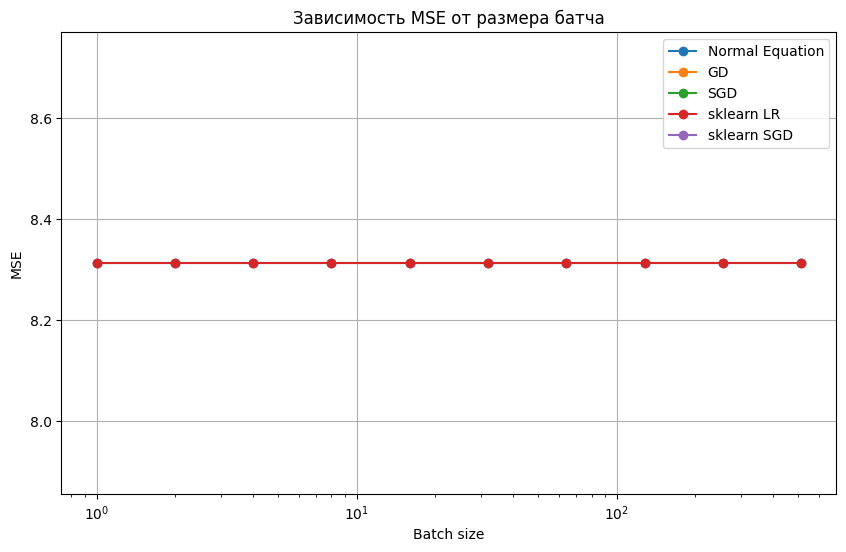


Таблица значений MSE для Зависимость MSE от размера батча:
            Normal Equation  GD  SGD  sklearn LR  sklearn SGD
Batch size                                                   
1                  8.313329 NaN  NaN    8.313329          NaN
2                  8.313329 NaN  NaN    8.313329          NaN
4                  8.313329 NaN  NaN    8.313329          NaN
8                  8.313329 NaN  NaN    8.313329          NaN
16                 8.313329 NaN  NaN    8.313329          NaN
32                 8.313329 NaN  NaN    8.313329          NaN
64                 8.313329 NaN  NaN    8.313329          NaN
128                8.313329 NaN  NaN    8.313329          NaN
256                8.313329 NaN  NaN    8.313329          NaN
512                8.313329 NaN  NaN    8.313329          NaN


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline

# ---------- Загрузка данных (ожидается файл data.csv) ----------
from google.colab import files
print("Загрузите файл data.csv:")
uploaded = files.upload()  # выберите файл data.csv на компьютере

df = pd.read_csv('data.csv')
X = df[['x']].values
y = df['y'].values

print(f"Данные загружены. X shape: {X.shape}, y shape: {y.shape}")

# ---------- Реализации методов ----------
def normal_equation(X, y, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def gradient_descent(X, y, lr=0.01, epochs=1000, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        w -= lr * 2 * X.T @ (X @ w - y)
    return w

def sgd(X, y, lr=0.01, epochs=100, batch_size=32, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            w -= lr * 2 * Xb.T @ (Xb @ w - yb)
    return w

# ---------- Константы ----------
Xwb = np.hstack([np.ones((X.shape[0], 1)), X])
w_ne = normal_equation(X, y)
mse_ne = mean_squared_error(y, Xwb @ w_ne)
lr_sk = LinearRegression().fit(X, y)
mse_lr_sk = mean_squared_error(y, lr_sk.predict(X))

# ---------- Универсальная функция с возвратом NaN при расходимости ----------
def compute_mse(method, lr=None, epochs=None, batch_size=None):
    np.random.seed(42)
    try:
        if method == 'ne':
            return mse_ne
        elif method == 'gd':
            w = gradient_descent(X, y, lr=lr, epochs=epochs)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'sgd':
            w = sgd(X, y, lr=lr, epochs=epochs, batch_size=batch_size)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'lr_sk':
            return mse_lr_sk
        elif method == 'sgd_sk':
            sgd_sk = SGDRegressor(
                fit_intercept=True,
                max_iter=epochs,
                eta0=lr,
                learning_rate='constant',
                penalty=None,
                tol=None,
                batch_size=batch_size,
                random_state=42
            )
            sgd_sk.fit(X, y)
            y_pred = sgd_sk.predict(X)
            if np.any(np.isnan(y_pred)):
                return np.nan
            return mean_squared_error(y, y_pred)
        else:
            raise ValueError('Unknown method')
    except Exception:
        return np.nan

# ---------- Диапазоны гиперпараметров ----------
lr_range = np.logspace(-8, -1, 8)      # от 1e-8 до 0.1
epochs_range = [2, 20, 200, 2000, 20000]
batch_range = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

DEFAULT_LR = 0.01
DEFAULT_EPOCHS = 1000
DEFAULT_BATCH = 32

methods = [
    ('ne', 'Normal Equation'),
    ('gd', 'GD'),
    ('sgd', 'SGD'),
    ('lr_sk', 'sklearn LR'),
    ('sgd_sk', 'sklearn SGD')
]

# ---------- Функция для построения графика и вывода таблицы ----------
def plot_and_table(param_values, param_name, xlabel, title, filename):
    plt.figure(figsize=(10, 6))
    results = {}
    for method, label in methods:
        mses = []
        for val in param_values:
            if param_name == 'lr':
                mse = compute_mse(method, lr=val, epochs=DEFAULT_EPOCHS, batch_size=DEFAULT_BATCH)
            elif param_name == 'epochs':
                mse = compute_mse(method, lr=DEFAULT_LR, epochs=val, batch_size=DEFAULT_BATCH)
            elif param_name == 'batch':
                mse = compute_mse(method, lr=DEFAULT_LR, epochs=DEFAULT_EPOCHS, batch_size=val)
            mses.append(mse)
        results[label] = mses
        plt.semilogx(param_values, mses, marker='o', label=label)
    plt.xlabel(xlabel)
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Вывод таблицы
    df_table = pd.DataFrame(results, index=param_values)
    df_table.index.name = xlabel
    print(f"\nТаблица значений MSE для {title}:")
    print(df_table.round(6))
    return df_table

# ---------- Построение графиков и таблиц ----------
print("\n" + "="*60)
print("ГРАФИК 1: Зависимость MSE от learning rate")
table_lr = plot_and_table(lr_range, 'lr', 'Learning rate', 'Зависимость MSE от learning rate', 'lr_plot')

print("\n" + "="*60)
print("ГРАФИК 2: Зависимость MSE от количества эпох")
table_epochs = plot_and_table(epochs_range, 'epochs', 'Epochs', 'Зависимость MSE от количества эпох', 'epochs_plot')

print("\n" + "="*60)
print("ГРАФИК 3: Зависимость MSE от размера батча")
table_batch = plot_and_table(batch_range, 'batch', 'Batch size', 'Зависимость MSE от размера батча', 'batch_plot')

Загрузите файл data.csv:


Saving data.csv to data (2).csv
Данные загружены. X shape: (999, 1), y shape: (999,)

ГРАФИК 1: Зависимость MSE от learning rate


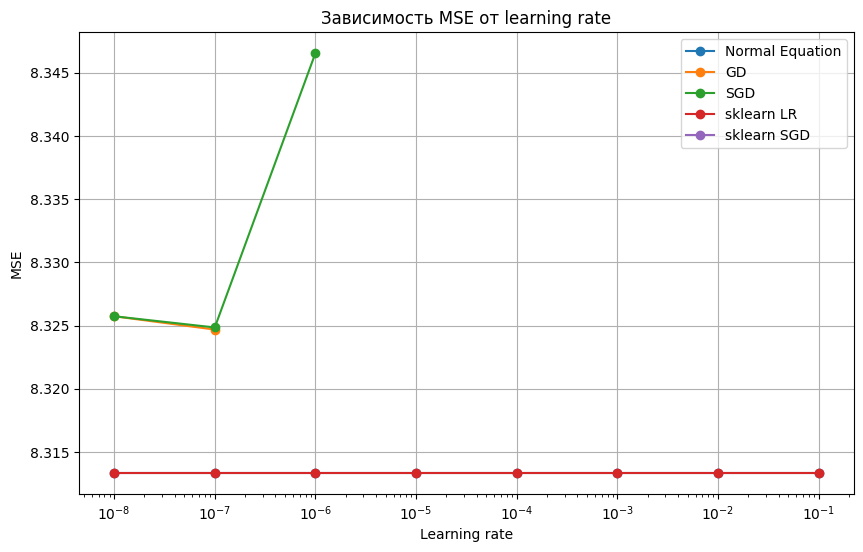


Таблица значений MSE для Зависимость MSE от learning rate:
               Normal Equation        GD       SGD  sklearn LR  sklearn SGD
Learning rate                                                              
1.000000e-08          8.313329  8.325737  8.325737    8.313329            -
1.000000e-07          8.313329  8.324683  8.324850    8.313329            -
1.000000e-06          8.313329         -  8.346550    8.313329            -
1.000000e-05          8.313329         -         -    8.313329            -
1.000000e-04          8.313329         -         -    8.313329            -
1.000000e-03          8.313329         -         -    8.313329            -
1.000000e-02          8.313329         -         -    8.313329            -
1.000000e-01          8.313329         -         -    8.313329            -

Выбран learning rate = 1.00e-08 для следующих графиков (наименьший работающий для GD).

ГРАФИК 2: Зависимость MSE от количества эпох


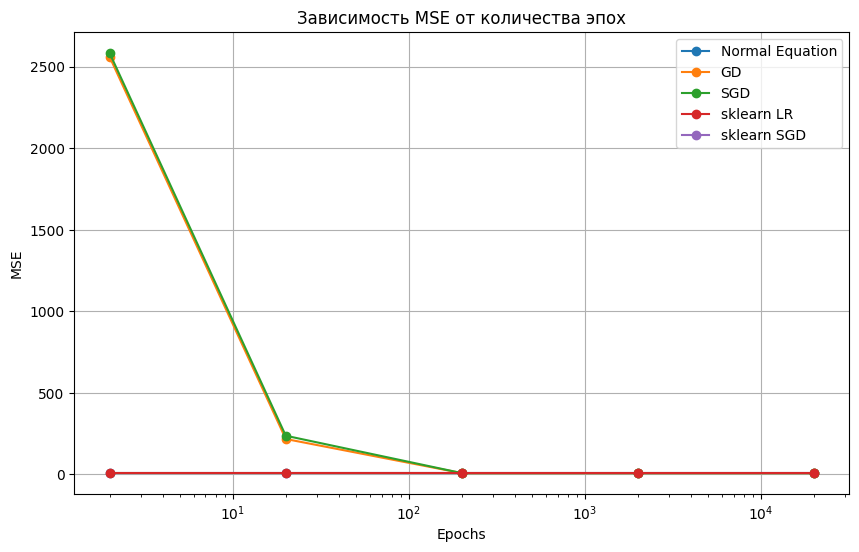


Таблица значений MSE для Зависимость MSE от количества эпох:
        Normal Equation           GD          SGD  sklearn LR  sklearn SGD
Epochs                                                                    
2              8.313329  2560.000199  2583.409888    8.313329            -
20             8.313329   217.565243   237.582879    8.313329            -
200            8.313329     8.325835     8.325835    8.313329            -
2000           8.313329     8.325615     8.325615    8.313329            -
20000          8.313329     8.323616     8.323616    8.313329            -

ГРАФИК 3: Зависимость MSE от размера батча


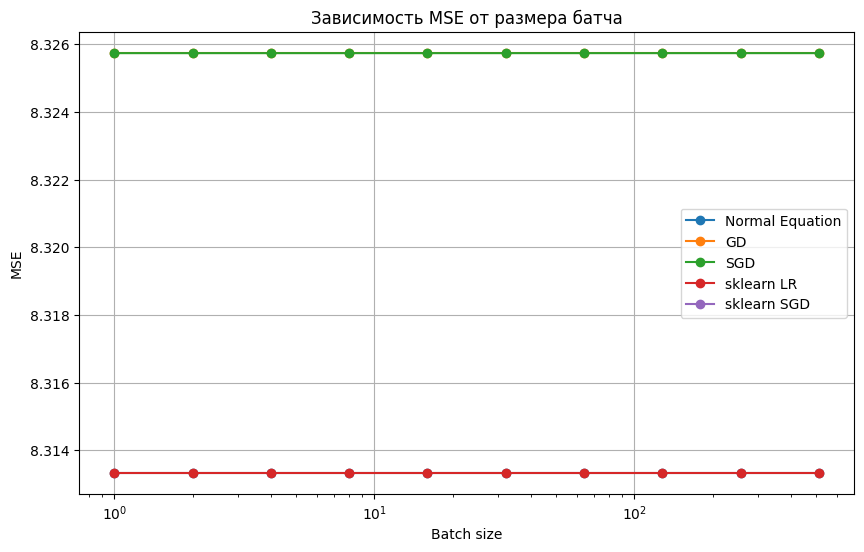


Таблица значений MSE для Зависимость MSE от размера батча:
            Normal Equation        GD       SGD  sklearn LR  sklearn SGD
Batch size                                                              
1                  8.313329  8.325737  8.325737    8.313329            -
2                  8.313329  8.325737  8.325737    8.313329            -
4                  8.313329  8.325737  8.325737    8.313329            -
8                  8.313329  8.325737  8.325737    8.313329            -
16                 8.313329  8.325737  8.325737    8.313329            -
32                 8.313329  8.325737  8.325737    8.313329            -
64                 8.313329  8.325737  8.325737    8.313329            -
128                8.313329  8.325737  8.325737    8.313329            -
256                8.313329  8.325737  8.325737    8.313329            -
512                8.313329  8.325737  8.325737    8.313329            -


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline

# ---------- Загрузка данных (ожидается файл data.csv) ----------
from google.colab import files
print("Загрузите файл data.csv:")
uploaded = files.upload()

df = pd.read_csv('data.csv')
X = df[['x']].values
y = df['y'].values

print(f"Данные загружены. X shape: {X.shape}, y shape: {y.shape}")

# ---------- Реализации методов ----------
def normal_equation(X, y, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def gradient_descent(X, y, lr=0.01, epochs=1000, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        w -= lr * 2 * X.T @ (X @ w - y)
    return w

def sgd(X, y, lr=0.01, epochs=100, batch_size=32, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            w -= lr * 2 * Xb.T @ (Xb @ w - yb)
    return w

# ---------- Константы ----------
Xwb = np.hstack([np.ones((X.shape[0], 1)), X])
w_ne = normal_equation(X, y)
mse_ne = mean_squared_error(y, Xwb @ w_ne)
lr_sk = LinearRegression().fit(X, y)
mse_lr_sk = mean_squared_error(y, lr_sk.predict(X))

# ---------- Универсальная функция с возвратом NaN при расходимости ----------
def compute_mse(method, lr=None, epochs=None, batch_size=None):
    np.random.seed(42)
    try:
        if method == 'ne':
            return mse_ne
        elif method == 'gd':
            w = gradient_descent(X, y, lr=lr, epochs=epochs)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'sgd':
            w = sgd(X, y, lr=lr, epochs=epochs, batch_size=batch_size)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'lr_sk':
            return mse_lr_sk
        elif method == 'sgd_sk':
            sgd_sk = SGDRegressor(
                fit_intercept=True,
                max_iter=epochs,
                eta0=lr,
                learning_rate='constant',
                penalty=None,
                tol=None,
                batch_size=batch_size,
                random_state=42
            )
            sgd_sk.fit(X, y)
            y_pred = sgd_sk.predict(X)
            if np.any(np.isnan(y_pred)):
                return np.nan
            return mean_squared_error(y, y_pred)
        else:
            raise ValueError('Unknown method')
    except Exception:
        return np.nan

# ---------- Диапазоны гиперпараметров ----------
lr_range = np.logspace(-8, -1, 8)      # от 1e-8 до 0.1
epochs_range = [2, 20, 200, 2000, 20000]
batch_range = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

# Начальные значения по умолчанию (будут переопределены после первого графика)
DEFAULT_LR = 0.01
DEFAULT_EPOCHS = 1000
DEFAULT_BATCH = 32

methods = [
    ('ne', 'Normal Equation'),
    ('gd', 'GD'),
    ('sgd', 'SGD'),
    ('lr_sk', 'sklearn LR'),
    ('sgd_sk', 'sklearn SGD')
]

# ---------- Функция для построения графика и вывода таблицы ----------
def plot_and_table(param_values, param_name, xlabel, title, filename):
    plt.figure(figsize=(10, 6))
    results = {}
    for method, label in methods:
        mses = []
        for val in param_values:
            if param_name == 'lr':
                mse = compute_mse(method, lr=val, epochs=DEFAULT_EPOCHS, batch_size=DEFAULT_BATCH)
            elif param_name == 'epochs':
                mse = compute_mse(method, lr=DEFAULT_LR, epochs=val, batch_size=DEFAULT_BATCH)
            elif param_name == 'batch':
                mse = compute_mse(method, lr=DEFAULT_LR, epochs=DEFAULT_EPOCHS, batch_size=val)
            mses.append(mse)
        results[label] = mses
        plt.semilogx(param_values, mses, marker='o', label=label)
    plt.xlabel(xlabel)
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Вывод таблицы
    df_table = pd.DataFrame(results, index=param_values)
    df_table.index.name = xlabel
    print(f"\nТаблица значений MSE для {title}:")
    # Заменяем NaN на прочерк для читаемости
    print(df_table.round(6).to_string(na_rep='-'))
    return df_table

# ---------- Сначала строим график learning rate и определяем оптимальный LR ----------
print("\n" + "="*60)
print("ГРАФИК 1: Зависимость MSE от learning rate")
table_lr = plot_and_table(lr_range, 'lr', 'Learning rate', 'Зависимость MSE от learning rate', 'lr_plot')

# Определяем лучший learning rate для GD (первый не-NaN или минимальный MSE среди не-NaN)
gd_mses = table_lr['GD'].values
valid_lr = lr_range[~np.isnan(gd_mses)]
if len(valid_lr) > 0:
    # Берем первый (самый маленький) работающий learning rate
    best_lr = valid_lr[0]
    print(f"\nВыбран learning rate = {best_lr:.2e} для следующих графиков (наименьший работающий для GD).")
else:
    best_lr = 1e-8  # запасной вариант
    print("\nGD не сошелся ни при одном learning rate, используем 1e-8.")

DEFAULT_LR = best_lr

# ---------- График 2: влияние числа эпох (с новым DEFAULT_LR) ----------
print("\n" + "="*60)
print("ГРАФИК 2: Зависимость MSE от количества эпох")
table_epochs = plot_and_table(epochs_range, 'epochs', 'Epochs', 'Зависимость MSE от количества эпох', 'epochs_plot')

# ---------- График 3: влияние размера батча (с новым DEFAULT_LR) ----------
print("\n" + "="*60)
print("ГРАФИК 3: Зависимость MSE от размера батча")
table_batch = plot_and_table(batch_range, 'batch', 'Batch size', 'Зависимость MSE от размера батча', 'batch_plot')

Загрузите файл data.csv:


Saving data.csv to data (3).csv
Данные загружены. X shape: (999, 1), y shape: (999,)

ГРАФИК 1: Зависимость MSE от learning rate


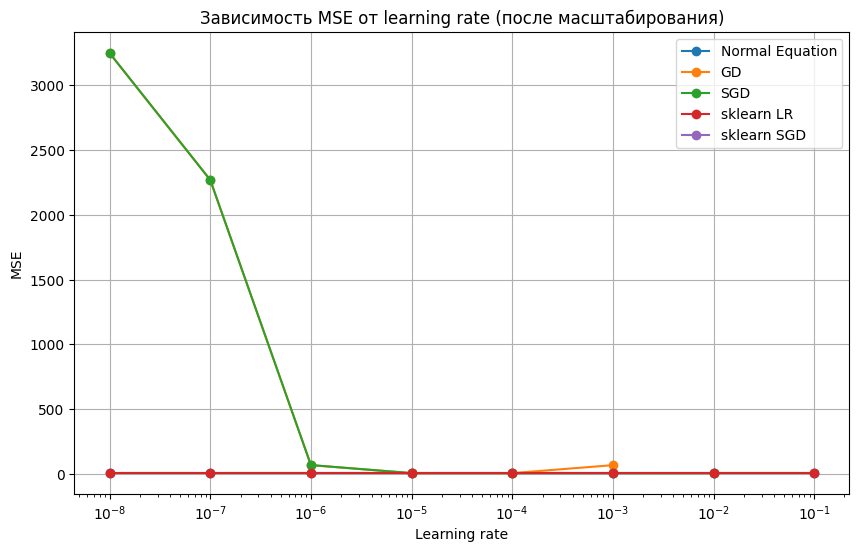


Таблица значений MSE для Зависимость MSE от learning rate (после масштабирования):
               Normal Equation           GD          SGD  sklearn LR  sklearn SGD
Learning rate                                                                    
1.000000e-08          8.313329  3245.435934  3245.437183    8.313329            -
1.000000e-07          8.313329  2267.501029  2267.588249    8.313329            -
1.000000e-06          8.313329    70.020689    70.259705    8.313329            -
1.000000e-05          8.313329     8.313329     8.313329    8.313329            -
1.000000e-04          8.313329     8.313329     8.313332    8.313329            -
1.000000e-03          8.313329    69.773860     8.320042    8.313329            -
1.000000e-02          8.313329            -     8.470672    8.313329            -
1.000000e-01          8.313329            -            -    8.313329            -

Выбран learning rate = 1.00e-08 для следующих графиков (наименьший работающий для GD).

ГРАФИК 

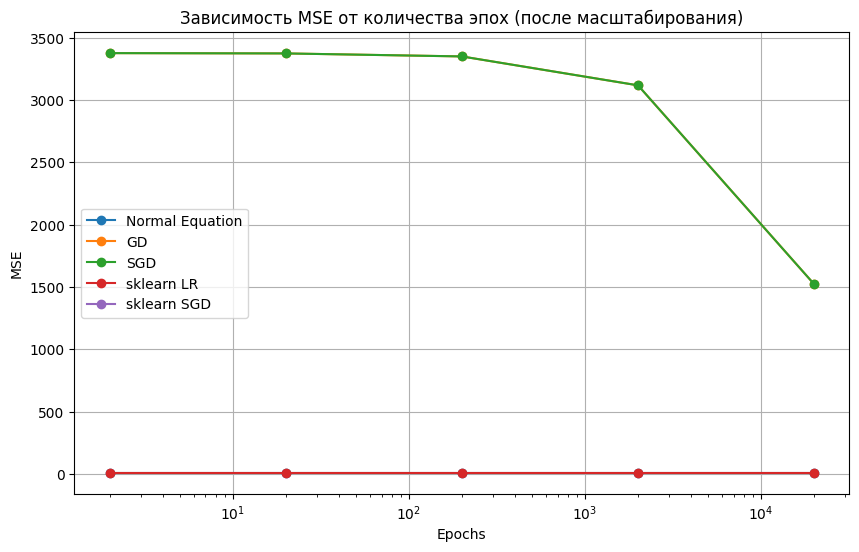


Таблица значений MSE для Зависимость MSE от количества эпох (после масштабирования):
        Normal Equation           GD          SGD  sklearn LR  sklearn SGD
Epochs                                                                    
2              8.313329  3377.142741  3377.142744    8.313329            -
20             8.313329  3374.720457  3374.720483    8.313329            -
200            8.313329  3350.593198  3350.593456    8.313329            -
2000           8.313329  3118.629709  3118.632111    8.313329            -
20000          8.313329  1523.346396  1523.358092    8.313329            -

ГРАФИК 3: Зависимость MSE от размера батча


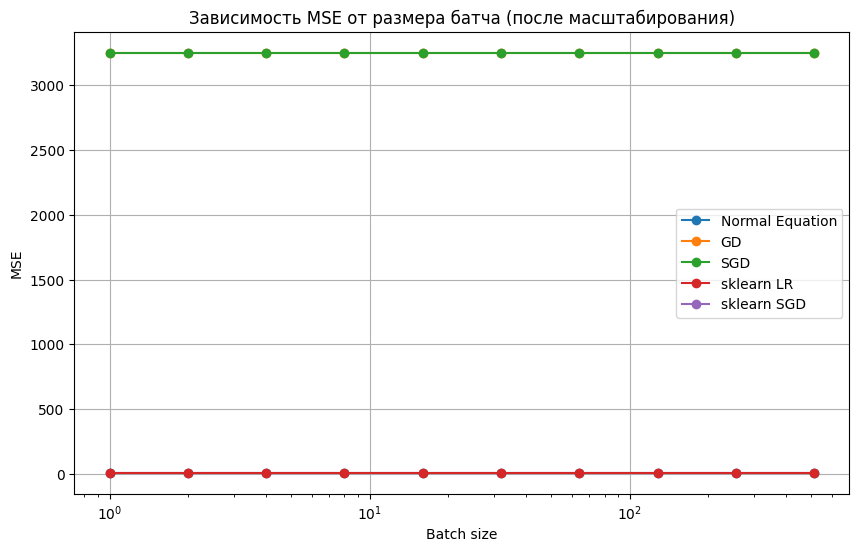


Таблица значений MSE для Зависимость MSE от размера батча (после масштабирования):
            Normal Equation           GD          SGD  sklearn LR  sklearn SGD
Batch size                                                                    
1                  8.313329  3245.435934  3245.437223    8.313329            -
2                  8.313329  3245.435934  3245.437222    8.313329            -
4                  8.313329  3245.435934  3245.437219    8.313329            -
8                  8.313329  3245.435934  3245.437214    8.313329            -
16                 8.313329  3245.435934  3245.437204    8.313329            -
32                 8.313329  3245.435934  3245.437183    8.313329            -
64                 8.313329  3245.435934  3245.437143    8.313329            -
128                8.313329  3245.435934  3245.437062    8.313329            -
256                8.313329  3245.435934  3245.436901    8.313329            -
512                8.313329  3245.435934  3245.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

%matplotlib inline

# ---------- Загрузка данных (ожидается файл data.csv) ----------
from google.colab import files
print("Загрузите файл data.csv:")
uploaded = files.upload()

df = pd.read_csv('data.csv')
X_raw = df[['x']].values
y = df['y'].values

print(f"Данные загружены. X shape: {X_raw.shape}, y shape: {y.shape}")

# ---------- Масштабирование признаков ----------
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)   # теперь X имеет среднее 0 и дисперсию 1

# ---------- Реализации методов ----------
def normal_equation(X, y, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def gradient_descent(X, y, lr=0.01, epochs=1000, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        w -= lr * 2 * X.T @ (X @ w - y)
    return w

def sgd(X, y, lr=0.01, epochs=100, batch_size=32, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            w -= lr * 2 * Xb.T @ (Xb @ w - yb)
    return w

# ---------- Константы (после масштабирования) ----------
Xwb = np.hstack([np.ones((X.shape[0], 1)), X])
w_ne = normal_equation(X, y)
mse_ne = mean_squared_error(y, Xwb @ w_ne)
lr_sk = LinearRegression().fit(X, y)
mse_lr_sk = mean_squared_error(y, lr_sk.predict(X))

# ---------- Универсальная функция с возвратом NaN при расходимости ----------
def compute_mse(method, lr=None, epochs=None, batch_size=None):
    np.random.seed(42)
    try:
        if method == 'ne':
            return mse_ne
        elif method == 'gd':
            w = gradient_descent(X, y, lr=lr, epochs=epochs)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'sgd':
            w = sgd(X, y, lr=lr, epochs=epochs, batch_size=batch_size)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'lr_sk':
            return mse_lr_sk
        elif method == 'sgd_sk':
            sgd_sk = SGDRegressor(
                fit_intercept=True,
                max_iter=epochs,
                eta0=lr,
                learning_rate='constant',
                penalty=None,
                tol=None,
                batch_size=batch_size,
                random_state=42
            )
            sgd_sk.fit(X, y)   # X уже масштабированы
            y_pred = sgd_sk.predict(X)
            if np.any(np.isnan(y_pred)):
                return np.nan
            return mean_squared_error(y, y_pred)
        else:
            raise ValueError('Unknown method')
    except Exception:
        return np.nan

# ---------- Диапазоны гиперпараметров ----------
lr_range = np.logspace(-8, -1, 8)      # от 1e-8 до 0.1 (после масштабирования 0.1 может быть великоват, но посмотрим)
epochs_range = [2, 20, 200, 2000, 20000]
batch_range = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

DEFAULT_LR = 0.01      # будет переопределён после первого графика
DEFAULT_EPOCHS = 1000
DEFAULT_BATCH = 32

methods = [
    ('ne', 'Normal Equation'),
    ('gd', 'GD'),
    ('sgd', 'SGD'),
    ('lr_sk', 'sklearn LR'),
    ('sgd_sk', 'sklearn SGD')
]

# ---------- Функция для построения графика и вывода таблицы ----------
def plot_and_table(param_values, param_name, xlabel, title, filename):
    plt.figure(figsize=(10, 6))
    results = {}
    for method, label in methods:
        mses = []
        for val in param_values:
            if param_name == 'lr':
                mse = compute_mse(method, lr=val, epochs=DEFAULT_EPOCHS, batch_size=DEFAULT_BATCH)
            elif param_name == 'epochs':
                mse = compute_mse(method, lr=DEFAULT_LR, epochs=val, batch_size=DEFAULT_BATCH)
            elif param_name == 'batch':
                mse = compute_mse(method, lr=DEFAULT_LR, epochs=DEFAULT_EPOCHS, batch_size=val)
            mses.append(mse)
        results[label] = mses
        plt.semilogx(param_values, mses, marker='o', label=label)
    plt.xlabel(xlabel)
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Вывод таблицы
    df_table = pd.DataFrame(results, index=param_values)
    df_table.index.name = xlabel
    print(f"\nТаблица значений MSE для {title}:")
    print(df_table.round(6).to_string(na_rep='-'))
    return df_table

# ---------- Сначала строим график learning rate и определяем оптимальный LR ----------
print("\n" + "="*60)
print("ГРАФИК 1: Зависимость MSE от learning rate")
table_lr = plot_and_table(lr_range, 'lr', 'Learning rate', 'Зависимость MSE от learning rate (после масштабирования)', 'lr_plot')

# Определяем лучший learning rate для GD (первый не-NaN или минимальный MSE среди не-NaN)
gd_mses = table_lr['GD'].values
valid_lr = lr_range[~np.isnan(gd_mses)]
if len(valid_lr) > 0:
    best_lr = valid_lr[0]   # наименьший работающий
    print(f"\nВыбран learning rate = {best_lr:.2e} для следующих графиков (наименьший работающий для GD).")
else:
    best_lr = 1e-8
    print("\nGD не сошелся ни при одном learning rate, используем 1e-8.")

DEFAULT_LR = best_lr

# ---------- График 2: влияние числа эпох ----------
print("\n" + "="*60)
print("ГРАФИК 2: Зависимость MSE от количества эпох")
table_epochs = plot_and_table(epochs_range, 'epochs', 'Epochs', 'Зависимость MSE от количества эпох (после масштабирования)', 'epochs_plot')

# ---------- График 3: влияние размера батча ----------
print("\n" + "="*60)
print("ГРАФИК 3: Зависимость MSE от размера батча")
table_batch = plot_and_table(batch_range, 'batch', 'Batch size', 'Зависимость MSE от размера батча (после масштабирования)', 'batch_plot')

Загрузите файл data.csv:


Saving data.csv to data (4).csv
Данные загружены. X shape: (999, 1), y shape: (999,)

ГРАФИК 1: Зависимость MSE от learning rate


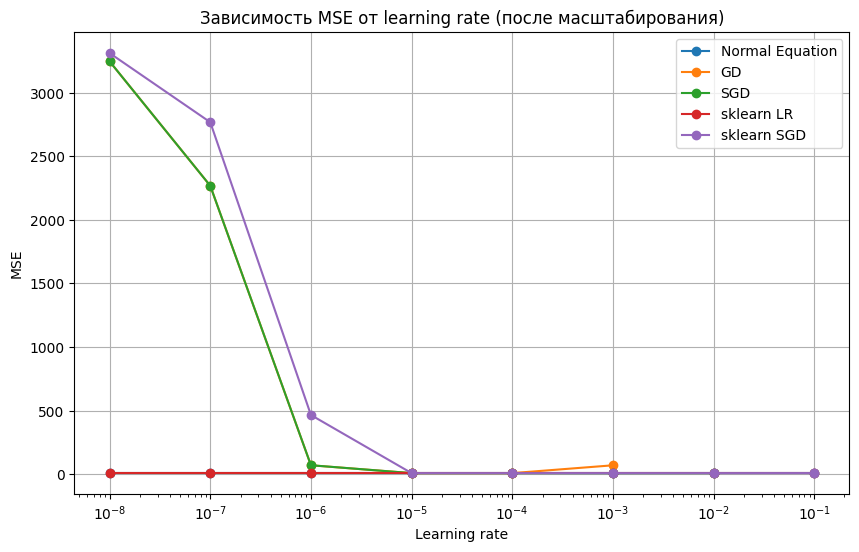


Таблица значений MSE для Зависимость MSE от learning rate (после масштабирования):
               Normal Equation           GD          SGD  sklearn LR  sklearn SGD
Learning rate                                                                    
1.000000e-08          8.313329  3245.435934  3245.437183    8.313329  3310.765416
1.000000e-07          8.313329  2267.501029  2267.588249    8.313329  2767.249684
1.000000e-06          8.313329    70.020689    70.259705    8.313329   465.183031
1.000000e-05          8.313329     8.313329     8.313329    8.313329     8.313411
1.000000e-04          8.313329     8.313329     8.313332    8.313329     8.313361
1.000000e-03          8.313329    69.773860     8.320042    8.313329     8.314865
1.000000e-02          8.313329            -     8.470672    8.313329     8.348210
1.000000e-01          8.313329            -            -    8.313329     8.732265

Выбран learning rate = 1.00e-04 (MSE = 8.313329) для следующих графиков.

ГРАФИК 2: Зависимость

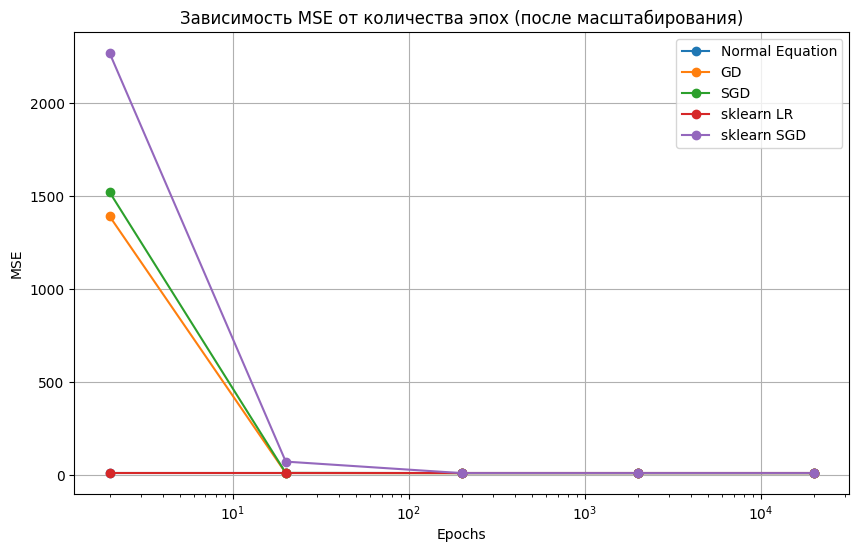


Таблица значений MSE для Зависимость MSE от количества эпох (после масштабирования):
        Normal Equation           GD          SGD  sklearn LR  sklearn SGD
Epochs                                                                    
2              8.313329  1389.676642  1519.252432    8.313329  2267.536287
20             8.313329     8.765660     9.423590    8.313329    70.248428
200            8.313329     8.313329     8.313338    8.313329     8.313361
2000           8.313329     8.313329     8.313334    8.313329     8.313361
20000          8.313329     8.313329     8.313333    8.313329     8.313361

ГРАФИК 3: Зависимость MSE от размера батча


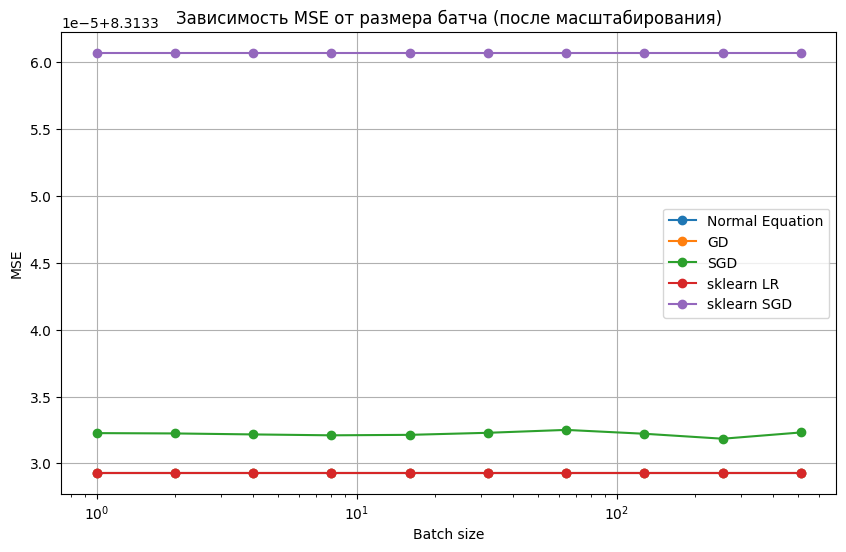


Таблица значений MSE для Зависимость MSE от размера батча (после масштабирования):
            Normal Equation        GD       SGD  sklearn LR  sklearn SGD
Batch size                                                              
1                  8.313329  8.313329  8.313332    8.313329     8.313361
2                  8.313329  8.313329  8.313332    8.313329     8.313361
4                  8.313329  8.313329  8.313332    8.313329     8.313361
8                  8.313329  8.313329  8.313332    8.313329     8.313361
16                 8.313329  8.313329  8.313332    8.313329     8.313361
32                 8.313329  8.313329  8.313332    8.313329     8.313361
64                 8.313329  8.313329  8.313333    8.313329     8.313361
128                8.313329  8.313329  8.313332    8.313329     8.313361
256                8.313329  8.313329  8.313332    8.313329     8.313361
512                8.313329  8.313329  8.313332    8.313329     8.313361


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

%matplotlib inline

# ---------- Загрузка данных ----------
from google.colab import files
print("Загрузите файл data.csv:")
uploaded = files.upload()

df = pd.read_csv('data.csv')
X_raw = df[['x']].values
y = df['y'].values

print(f"Данные загружены. X shape: {X_raw.shape}, y shape: {y.shape}")

# ---------- Масштабирование признаков ----------
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)   # теперь X имеет среднее 0 и дисперсию 1

# ---------- Реализации методов ----------
def normal_equation(X, y, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def gradient_descent(X, y, lr=0.01, epochs=1000, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        w -= lr * 2 * X.T @ (X @ w - y)
    return w

def sgd(X, y, lr=0.01, epochs=100, batch_size=32, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            w -= lr * 2 * Xb.T @ (Xb @ w - yb)
    return w

# ---------- Константы ----------
Xwb = np.hstack([np.ones((X.shape[0], 1)), X])
w_ne = normal_equation(X, y)
mse_ne = mean_squared_error(y, Xwb @ w_ne)
lr_sk = LinearRegression().fit(X, y)
mse_lr_sk = mean_squared_error(y, lr_sk.predict(X))

# ---------- Универсальная функция с возвратом NaN при расходимости ----------
def compute_mse(method, lr=None, epochs=None, batch_size=None):
    np.random.seed(42)
    try:
        if method == 'ne':
            return mse_ne
        elif method == 'gd':
            w = gradient_descent(X, y, lr=lr, epochs=epochs)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'sgd':
            w = sgd(X, y, lr=lr, epochs=epochs, batch_size=batch_size)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'lr_sk':
            return mse_lr_sk
        elif method == 'sgd_sk':
            # Упростим: без batch_size, используем значения по умолчанию
            sgd_sk = SGDRegressor(
                fit_intercept=True,
                max_iter=epochs,
                eta0=lr,
                learning_rate='constant',
                penalty=None,
                tol=1e-6,
                random_state=42
            )
            sgd_sk.fit(X, y)
            y_pred = sgd_sk.predict(X)
            if np.any(np.isnan(y_pred)):
                return np.nan
            return mean_squared_error(y, y_pred)
        else:
            raise ValueError('Unknown method')
    except Exception as e:
        # print(f"Error in {method} with lr={lr}, epochs={epochs}, batch={batch_size}: {e}")
        return np.nan

# ---------- Диапазоны гиперпараметров ----------
lr_range = np.logspace(-8, -1, 8)      # от 1e-8 до 0.1
epochs_range = [2, 20, 200, 2000, 20000]
batch_range = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

DEFAULT_LR = 0.01      # будет переопределён после первого графика
DEFAULT_EPOCHS = 1000
DEFAULT_BATCH = 32

methods = [
    ('ne', 'Normal Equation'),
    ('gd', 'GD'),
    ('sgd', 'SGD'),
    ('lr_sk', 'sklearn LR'),
    ('sgd_sk', 'sklearn SGD')
]

# ---------- Функция для построения графика и вывода таблицы ----------
def plot_and_table(param_values, param_name, xlabel, title, filename):
    plt.figure(figsize=(10, 6))
    results = {}
    for method, label in methods:
        mses = []
        for val in param_values:
            if param_name == 'lr':
                mse = compute_mse(method, lr=val, epochs=DEFAULT_EPOCHS, batch_size=DEFAULT_BATCH)
            elif param_name == 'epochs':
                mse = compute_mse(method, lr=DEFAULT_LR, epochs=val, batch_size=DEFAULT_BATCH)
            elif param_name == 'batch':
                mse = compute_mse(method, lr=DEFAULT_LR, epochs=DEFAULT_EPOCHS, batch_size=val)
            mses.append(mse)
        results[label] = mses
        plt.semilogx(param_values, mses, marker='o', label=label)
    plt.xlabel(xlabel)
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Вывод таблицы
    df_table = pd.DataFrame(results, index=param_values)
    df_table.index.name = xlabel
    print(f"\nТаблица значений MSE для {title}:")
    print(df_table.round(6).to_string(na_rep='-'))
    return df_table

# ---------- Сначала строим график learning rate и определяем оптимальный LR ----------
print("\n" + "="*60)
print("ГРАФИК 1: Зависимость MSE от learning rate")
table_lr = plot_and_table(lr_range, 'lr', 'Learning rate', 'Зависимость MSE от learning rate (после масштабирования)', 'lr_plot')

# Выбираем learning rate с наименьшим MSE для GD (среди не-NaN)
gd_mses = table_lr['GD'].values
valid_mask = ~np.isnan(gd_mses)
if np.any(valid_mask):
    valid_lr = lr_range[valid_mask]
    valid_mse = gd_mses[valid_mask]
    best_idx = np.argmin(valid_mse)
    best_lr = valid_lr[best_idx]
    print(f"\nВыбран learning rate = {best_lr:.2e} (MSE = {valid_mse[best_idx]:.6f}) для следующих графиков.")
else:
    best_lr = 1e-5   # запасной вариант
    print("\nGD не сошелся ни при одном learning rate, используем 1e-5.")

DEFAULT_LR = best_lr

# ---------- График 2: влияние числа эпох ----------
print("\n" + "="*60)
print("ГРАФИК 2: Зависимость MSE от количества эпох")
table_epochs = plot_and_table(epochs_range, 'epochs', 'Epochs', 'Зависимость MSE от количества эпох (после масштабирования)', 'epochs_plot')

# ---------- График 3: влияние размера батча ----------
print("\n" + "="*60)
print("ГРАФИК 3: Зависимость MSE от размера батча")
table_batch = plot_and_table(batch_range, 'batch', 'Batch size', 'Зависимость MSE от размера батча (после масштабирования)', 'batch_plot')

Загрузите файл data.csv:


Saving data.csv to data (5).csv
Данные загружены. X shape: (999, 1), y shape: (999,)

ГРАФИК 1: Зависимость MSE от learning rate


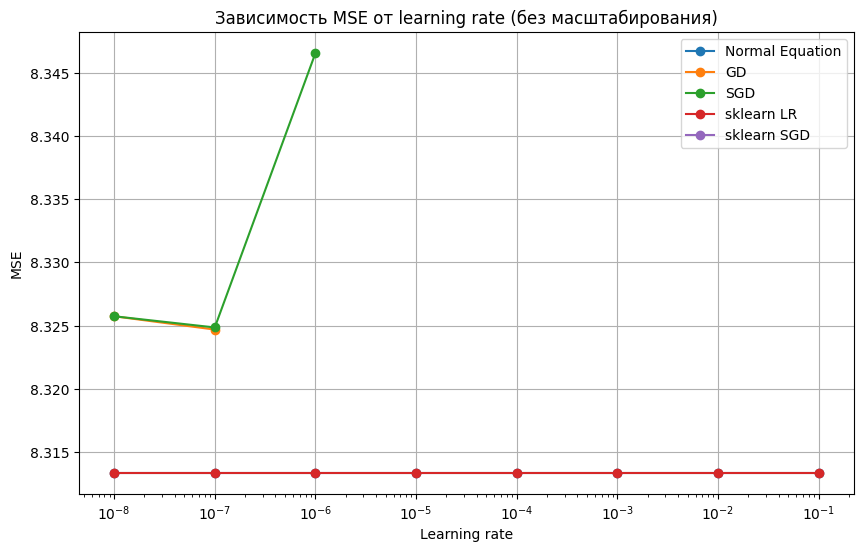


Таблица значений MSE для Зависимость MSE от learning rate (без масштабирования):
               Normal Equation        GD       SGD  sklearn LR  sklearn SGD
Learning rate                                                              
1.000000e-08          8.313329  8.325737  8.325737    8.313329            -
1.000000e-07          8.313329  8.324683  8.324850    8.313329            -
1.000000e-06          8.313329         -  8.346550    8.313329            -
1.000000e-05          8.313329         -         -    8.313329            -
1.000000e-04          8.313329         -         -    8.313329            -
1.000000e-03          8.313329         -         -    8.313329            -
1.000000e-02          8.313329         -         -    8.313329            -
1.000000e-01          8.313329         -         -    8.313329            -

Выбран learning rate = 1.00e-08 (наименьший работающий для GD).

ГРАФИК 2: Зависимость MSE от количества эпох


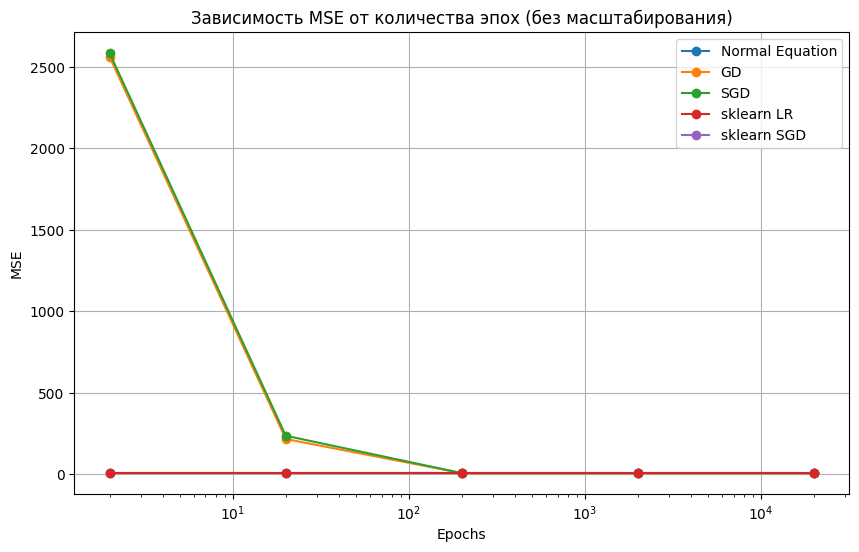


Таблица значений MSE для Зависимость MSE от количества эпох (без масштабирования):
        Normal Equation           GD          SGD  sklearn LR  sklearn SGD
Epochs                                                                    
2              8.313329  2560.000199  2583.409888    8.313329            -
20             8.313329   217.565243   237.582879    8.313329            -
200            8.313329     8.325835     8.325835    8.313329            -
2000           8.313329     8.325615     8.325615    8.313329            -
20000          8.313329     8.323616     8.323616    8.313329            -

ГРАФИК 3: Зависимость MSE от размера батча


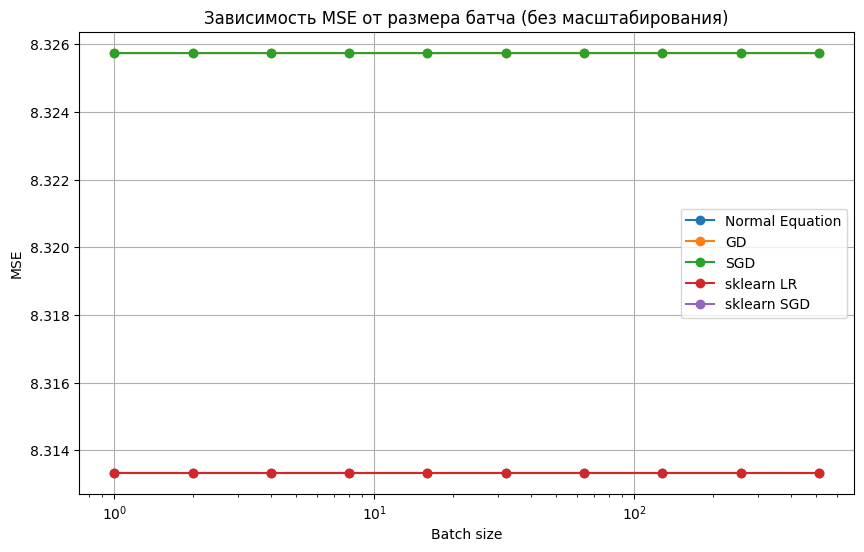


Таблица значений MSE для Зависимость MSE от размера батча (без масштабирования):
            Normal Equation        GD       SGD  sklearn LR  sklearn SGD
Batch size                                                              
1                  8.313329  8.325737  8.325737    8.313329            -
2                  8.313329  8.325737  8.325737    8.313329            -
4                  8.313329  8.325737  8.325737    8.313329            -
8                  8.313329  8.325737  8.325737    8.313329            -
16                 8.313329  8.325737  8.325737    8.313329            -
32                 8.313329  8.325737  8.325737    8.313329            -
64                 8.313329  8.325737  8.325737    8.313329            -
128                8.313329  8.325737  8.325737    8.313329            -
256                8.313329  8.325737  8.325737    8.313329            -
512                8.313329  8.325737  8.325737    8.313329            -


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline

# ---------- Загрузка данных ----------
from google.colab import files
print("Загрузите файл data.csv:")
uploaded = files.upload()

df = pd.read_csv('data.csv')
X = df[['x']].values   # без масштабирования
y = df['y'].values

print(f"Данные загружены. X shape: {X.shape}, y shape: {y.shape}")

# ---------- Реализации методов ----------
def normal_equation(X, y, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def gradient_descent(X, y, lr=0.01, epochs=1000, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        w -= lr * 2 * X.T @ (X @ w - y)
    return w

def sgd(X, y, lr=0.01, epochs=100, batch_size=32, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            w -= lr * 2 * Xb.T @ (Xb @ w - yb)
    return w

# ---------- Константы ----------
Xwb = np.hstack([np.ones((X.shape[0], 1)), X])
w_ne = normal_equation(X, y)
mse_ne = mean_squared_error(y, Xwb @ w_ne)
lr_sk = LinearRegression().fit(X, y)
mse_lr_sk = mean_squared_error(y, lr_sk.predict(X))

# ---------- Универсальная функция с возвратом NaN при расходимости ----------
def compute_mse(method, lr=None, epochs=None, batch_size=None):
    np.random.seed(42)
    try:
        if method == 'ne':
            return mse_ne
        elif method == 'gd':
            w = gradient_descent(X, y, lr=lr, epochs=epochs)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'sgd':
            w = sgd(X, y, lr=lr, epochs=epochs, batch_size=batch_size)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'lr_sk':
            return mse_lr_sk
        elif method == 'sgd_sk':
            sgd_sk = SGDRegressor(
                fit_intercept=True,
                max_iter=epochs,
                eta0=lr,
                learning_rate='constant',
                penalty=None,
                tol=None,
                batch_size=batch_size,  # возвращаем batch_size
                random_state=42
            )
            sgd_sk.fit(X, y)   # без масштабирования
            y_pred = sgd_sk.predict(X)
            if np.any(np.isnan(y_pred)):
                return np.nan
            return mean_squared_error(y, y_pred)
        else:
            raise ValueError('Unknown method')
    except Exception:
        return np.nan

# ---------- Диапазоны гиперпараметров ----------
lr_range = np.logspace(-8, -1, 8)      # от 1e-8 до 0.1
epochs_range = [2, 20, 200, 2000, 20000]
batch_range = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

DEFAULT_LR = 0.01      # будет переопределён
DEFAULT_EPOCHS = 1000
DEFAULT_BATCH = 32

methods = [
    ('ne', 'Normal Equation'),
    ('gd', 'GD'),
    ('sgd', 'SGD'),
    ('lr_sk', 'sklearn LR'),
    ('sgd_sk', 'sklearn SGD')
]

# ---------- Функция для построения графика и вывода таблицы ----------
def plot_and_table(param_values, param_name, xlabel, title, filename):
    plt.figure(figsize=(10, 6))
    results = {}
    for method, label in methods:
        mses = []
        for val in param_values:
            if param_name == 'lr':
                mse = compute_mse(method, lr=val, epochs=DEFAULT_EPOCHS, batch_size=DEFAULT_BATCH)
            elif param_name == 'epochs':
                mse = compute_mse(method, lr=DEFAULT_LR, epochs=val, batch_size=DEFAULT_BATCH)
            elif param_name == 'batch':
                mse = compute_mse(method, lr=DEFAULT_LR, epochs=DEFAULT_EPOCHS, batch_size=val)
            mses.append(mse)
        results[label] = mses
        plt.semilogx(param_values, mses, marker='o', label=label)
    plt.xlabel(xlabel)
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Вывод таблицы
    df_table = pd.DataFrame(results, index=param_values)
    df_table.index.name = xlabel
    print(f"\nТаблица значений MSE для {title}:")
    print(df_table.round(6).to_string(na_rep='-'))
    return df_table

# ---------- Сначала строим график learning rate ----------
print("\n" + "="*60)
print("ГРАФИК 1: Зависимость MSE от learning rate")
table_lr = plot_and_table(lr_range, 'lr', 'Learning rate', 'Зависимость MSE от learning rate (без масштабирования)', 'lr_plot')

# Выбираем наименьший работающий learning rate для GD (как в первом варианте)
gd_mses = table_lr['GD'].values
valid_lr = lr_range[~np.isnan(gd_mses)]
if len(valid_lr) > 0:
    best_lr = valid_lr[0]
    print(f"\nВыбран learning rate = {best_lr:.2e} (наименьший работающий для GD).")
else:
    best_lr = 1e-8
    print("\nGD не сошелся ни при одном learning rate, используем 1e-8.")

DEFAULT_LR = best_lr

# ---------- График 2: влияние числа эпох ----------
print("\n" + "="*60)
print("ГРАФИК 2: Зависимость MSE от количества эпох")
table_epochs = plot_and_table(epochs_range, 'epochs', 'Epochs', 'Зависимость MSE от количества эпох (без масштабирования)', 'epochs_plot')

# ---------- График 3: влияние размера батча ----------
print("\n" + "="*60)
print("ГРАФИК 3: Зависимость MSE от размера батча")
table_batch = plot_and_table(batch_range, 'batch', 'Batch size', 'Зависимость MSE от размера батча (без масштабирования)', 'batch_plot')

Данные загружены. X shape: (999, 1), y shape: (999,)

ГРАФИК 1: Зависимость MSE от learning rate


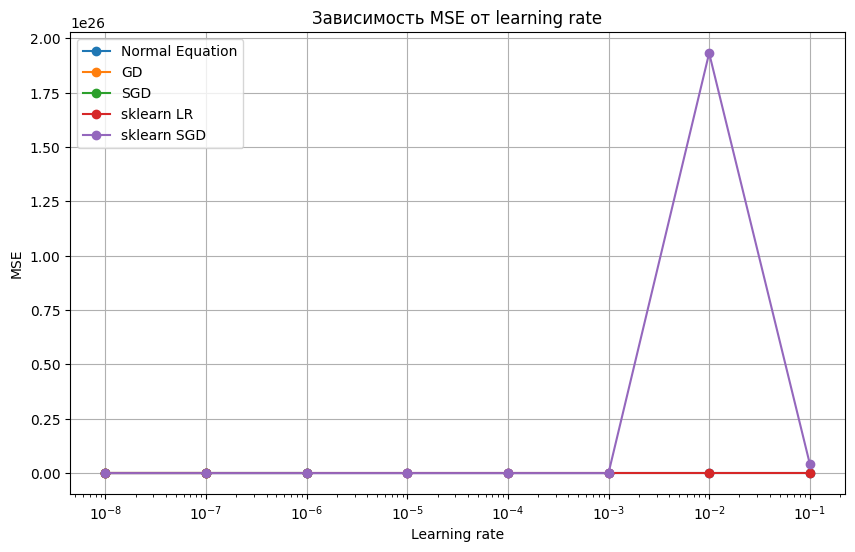


Таблица значений MSE для Зависимость MSE от learning rate:
               Normal Equation        GD       SGD  sklearn LR   sklearn SGD
Learning rate                                                               
1.000000e-08          8.313329  8.325737  8.325737    8.313329  8.325798e+00
1.000000e-07          8.313329  8.324683  8.324850    8.313329  8.325257e+00
1.000000e-06          8.313329         -  8.346550    8.313329  8.321114e+00
1.000000e-05          8.313329         -         -    8.313329  8.315080e+00
1.000000e-04          8.313329         -         -    8.313329  1.340738e+01
1.000000e-03          8.313329         -         -    8.313329  4.890101e+20
1.000000e-02          8.313329         -         -    8.313329  1.932537e+26
1.000000e-01          8.313329         -         -    8.313329  4.280040e+24

Выбран learning rate = 1.00e-08 (наименьший работающий для GD).

ГРАФИК 2: Зависимость MSE от количества эпох


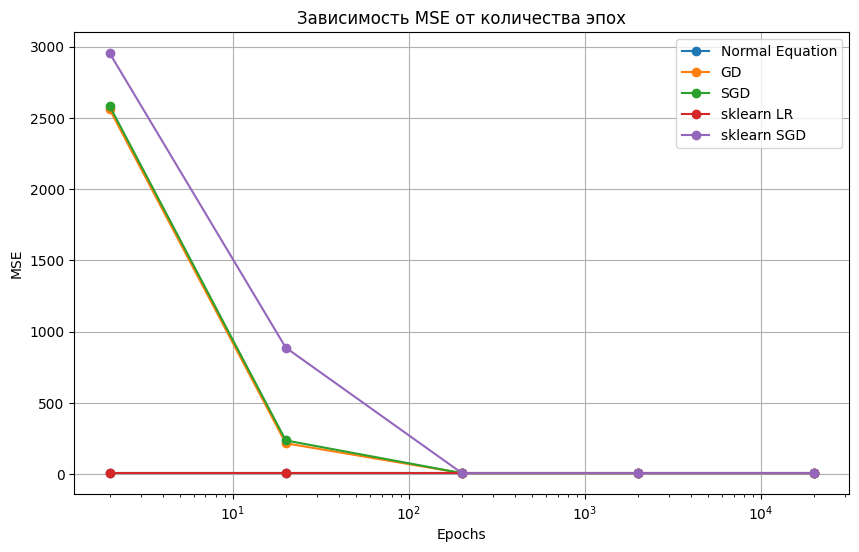


Таблица значений MSE для Зависимость MSE от количества эпох:
        Normal Equation           GD          SGD  sklearn LR  sklearn SGD
Epochs                                                                    
2              8.313329  2560.000199  2583.409888    8.313329  2954.214186
20             8.313329   217.565243   237.582879    8.313329   888.456215
200            8.313329     8.325835     8.325835    8.313329     8.330808
2000           8.313329     8.325615     8.325615    8.313329     8.325737
20000          8.313329     8.323616     8.323616    8.313329     8.324683

ГРАФИК 3: Зависимость MSE от размера батча


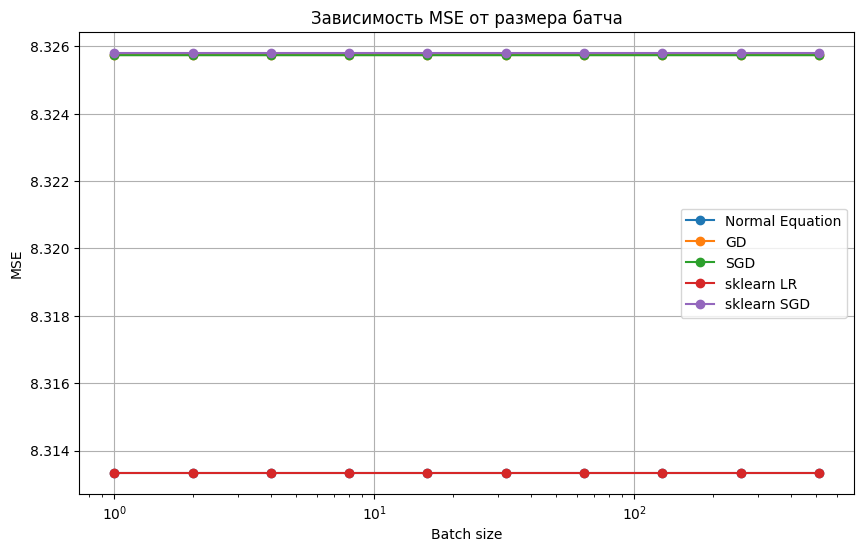


Таблица значений MSE для Зависимость MSE от размера батча:
            Normal Equation        GD       SGD  sklearn LR  sklearn SGD
Batch size                                                              
1                  8.313329  8.325737  8.325737    8.313329     8.325798
2                  8.313329  8.325737  8.325737    8.313329     8.325798
4                  8.313329  8.325737  8.325737    8.313329     8.325798
8                  8.313329  8.325737  8.325737    8.313329     8.325798
16                 8.313329  8.325737  8.325737    8.313329     8.325798
32                 8.313329  8.325737  8.325737    8.313329     8.325798
64                 8.313329  8.325737  8.325737    8.313329     8.325798
128                8.313329  8.325737  8.325737    8.313329     8.325798
256                8.313329  8.325737  8.325737    8.313329     8.325798
512                8.313329  8.325737  8.325737    8.313329     8.325798


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline

# ---------- Загрузка данных (файл data.csv должен лежать в папке с ноутбуком) ----------
df = pd.read_csv('data.csv')
X = df[['x']].values
y = df['y'].values

print(f"Данные загружены. X shape: {X.shape}, y shape: {y.shape}")

# ---------- Реализации методов ----------
def normal_equation(X, y, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def gradient_descent(X, y, lr=0.01, epochs=1000, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        w -= lr * 2 * X.T @ (X @ w - y)
    return w

def sgd(X, y, lr=0.01, epochs=100, batch_size=32, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            w -= lr * 2 * Xb.T @ (Xb @ w - yb)
    return w

# ---------- Константы ----------
Xwb = np.hstack([np.ones((X.shape[0], 1)), X])
w_ne = normal_equation(X, y)
mse_ne = mean_squared_error(y, Xwb @ w_ne)
lr_sk = LinearRegression().fit(X, y)
mse_lr_sk = mean_squared_error(y, lr_sk.predict(X))

# ---------- Универсальная функция с возвратом NaN при расходимости ----------
def compute_mse(method, lr=None, epochs=None, batch_size=None):
    np.random.seed(42)
    try:
        if method == 'ne':
            return mse_ne
        elif method == 'gd':
            w = gradient_descent(X, y, lr=lr, epochs=epochs)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'sgd':
            w = sgd(X, y, lr=lr, epochs=epochs, batch_size=batch_size)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'lr_sk':
            return mse_lr_sk
        elif method == 'sgd_sk':
            # batch_size не передаём, используем значение по умолчанию
            sgd_sk = SGDRegressor(
                fit_intercept=True,
                max_iter=epochs,
                eta0=lr,
                learning_rate='constant',
                penalty=None,
                tol=None,
                random_state=42
            )
            sgd_sk.fit(X, y)
            y_pred = sgd_sk.predict(X)
            if np.any(np.isnan(y_pred)):
                return np.nan
            return mean_squared_error(y, y_pred)
        else:
            raise ValueError('Unknown method')
    except Exception:
        return np.nan

# ---------- Диапазоны гиперпараметров ----------
lr_range = np.logspace(-8, -1, 8)      # от 1e-8 до 0.1
epochs_range = [2, 20, 200, 2000, 20000]
batch_range = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

DEFAULT_EPOCHS = 1000
DEFAULT_BATCH = 32

methods = [
    ('ne', 'Normal Equation'),
    ('gd', 'GD'),
    ('sgd', 'SGD'),
    ('lr_sk', 'sklearn LR'),
    ('sgd_sk', 'sklearn SGD')
]

# ---------- Функция для построения графика и вывода таблицы ----------
def plot_and_table(param_values, param_name, xlabel, title):
    plt.figure(figsize=(10, 6))
    results = {}
    for method, label in methods:
        mses = []
        for val in param_values:
            if param_name == 'lr':
                mse = compute_mse(method, lr=val, epochs=DEFAULT_EPOCHS, batch_size=DEFAULT_BATCH)
            elif param_name == 'epochs':
                mse = compute_mse(method, lr=best_lr, epochs=val, batch_size=DEFAULT_BATCH)
            elif param_name == 'batch':
                mse = compute_mse(method, lr=best_lr, epochs=DEFAULT_EPOCHS, batch_size=val)
            mses.append(mse)
        results[label] = mses
        plt.semilogx(param_values, mses, marker='o', label=label)
    plt.xlabel(xlabel)
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    df_table = pd.DataFrame(results, index=param_values)
    df_table.index.name = xlabel
    print(f"\nТаблица значений MSE для {title}:")
    print(df_table.round(6).to_string(na_rep='-'))
    return df_table

# ---------- Определяем best_lr по первому графику ----------
print("\n" + "="*60)
print("ГРАФИК 1: Зависимость MSE от learning rate")
table_lr = plot_and_table(lr_range, 'lr', 'Learning rate', 'Зависимость MSE от learning rate')

gd_mses = table_lr['GD'].values
valid_lr = lr_range[~np.isnan(gd_mses)]
if len(valid_lr) > 0:
    best_lr = valid_lr[0]
    print(f"\nВыбран learning rate = {best_lr:.2e} (наименьший работающий для GD).")
else:
    best_lr = 1e-8
    print("\nGD не сошелся ни при одном learning rate, используем 1e-8.")

# ---------- График 2: влияние числа эпох ----------
print("\n" + "="*60)
print("ГРАФИК 2: Зависимость MSE от количества эпох")
table_epochs = plot_and_table(epochs_range, 'epochs', 'Epochs', 'Зависимость MSE от количества эпох')

# ---------- График 3: влияние размера батча ----------
print("\n" + "="*60)
print("ГРАФИК 3: Зависимость MSE от размера батча")
table_batch = plot_and_table(batch_range, 'batch', 'Batch size', 'Зависимость MSE от размера батча')

Данные загружены. X shape: (999, 1), y shape: (999,)

ГРАФИК 1 (MSE): Зависимость MSE от learning rate


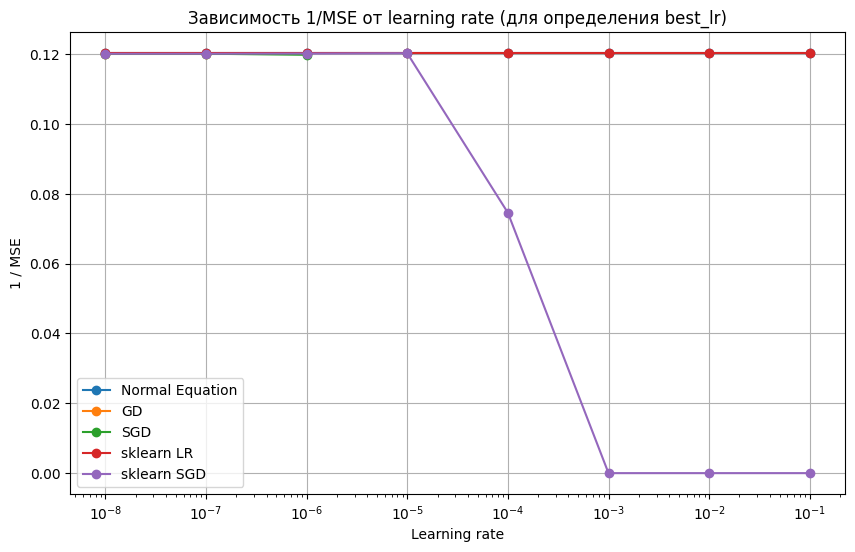


Таблица значений 1/MSE для Зависимость 1/MSE от learning rate (для определения best_lr):
               Normal Equation        GD       SGD  sklearn LR  sklearn SGD
Learning rate                                                              
1.000000e-08          0.120289  0.120109  0.120109    0.120289     0.120109
1.000000e-07          0.120289  0.120125  0.120122    0.120289     0.120116
1.000000e-06          0.120289         -  0.119810    0.120289     0.120176
1.000000e-05          0.120289         -         -    0.120289     0.120263
1.000000e-04          0.120289         -         -    0.120289     0.074586
1.000000e-03          0.120289         -         -    0.120289     0.000000
1.000000e-02          0.120289         -         -    0.120289     0.000000
1.000000e-01          0.120289         -         -    0.120289     0.000000

Выбран learning rate = 1.00e-08 (наименьший работающий для GD).

ГРАФИК 2: Зависимость 1/MSE от learning rate (все методы)


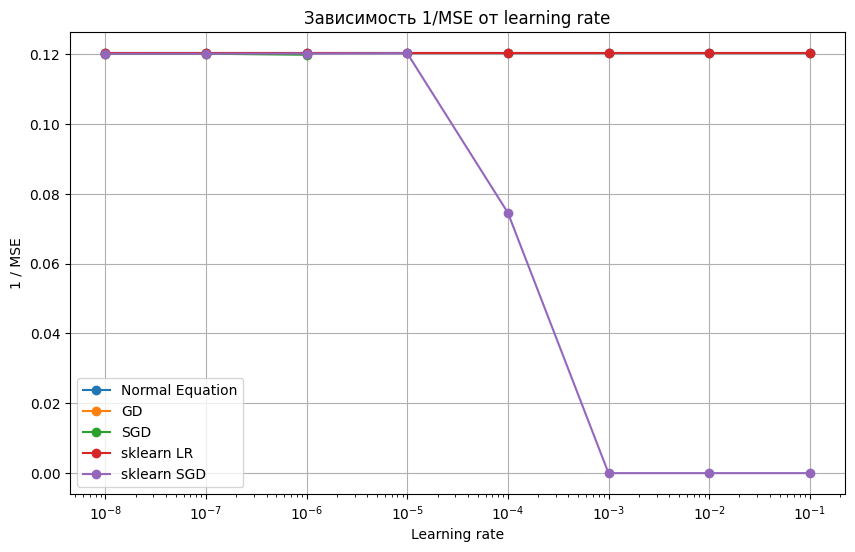


Таблица значений 1/MSE для Зависимость 1/MSE от learning rate:
               Normal Equation        GD       SGD  sklearn LR  sklearn SGD
Learning rate                                                              
1.000000e-08          0.120289  0.120109  0.120109    0.120289     0.120109
1.000000e-07          0.120289  0.120125  0.120122    0.120289     0.120116
1.000000e-06          0.120289         -  0.119810    0.120289     0.120176
1.000000e-05          0.120289         -         -    0.120289     0.120263
1.000000e-04          0.120289         -         -    0.120289     0.074586
1.000000e-03          0.120289         -         -    0.120289     0.000000
1.000000e-02          0.120289         -         -    0.120289     0.000000
1.000000e-01          0.120289         -         -    0.120289     0.000000

ГРАФИК 3: Зависимость 1/MSE от количества эпох


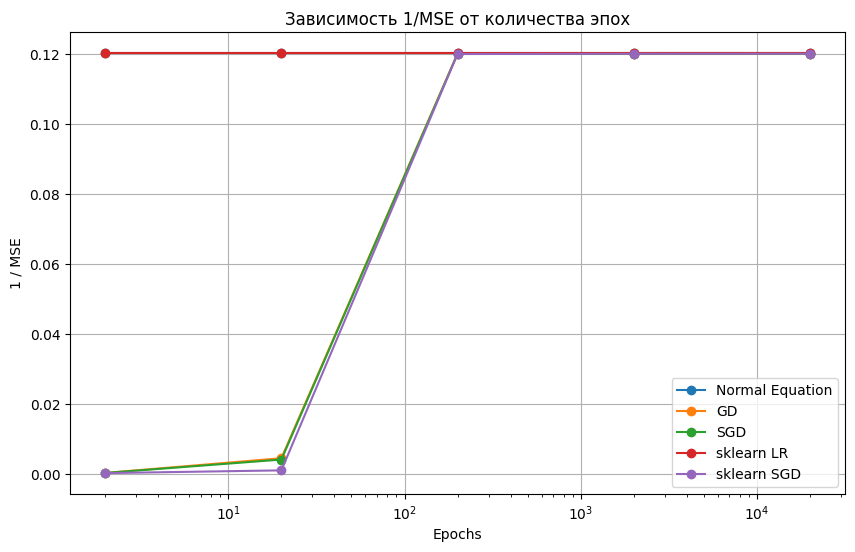


Таблица значений 1/MSE для Зависимость 1/MSE от количества эпох:
        Normal Equation        GD       SGD  sklearn LR  sklearn SGD
Epochs                                                              
2              0.120289  0.000391  0.000387    0.120289     0.000338
20             0.120289  0.004596  0.004209    0.120289     0.001126
200            0.120289  0.120108  0.120108    0.120289     0.120036
2000           0.120289  0.120111  0.120111    0.120289     0.120109
20000          0.120289  0.120140  0.120140    0.120289     0.120125

ГРАФИК 4: Зависимость 1/MSE от размера батча


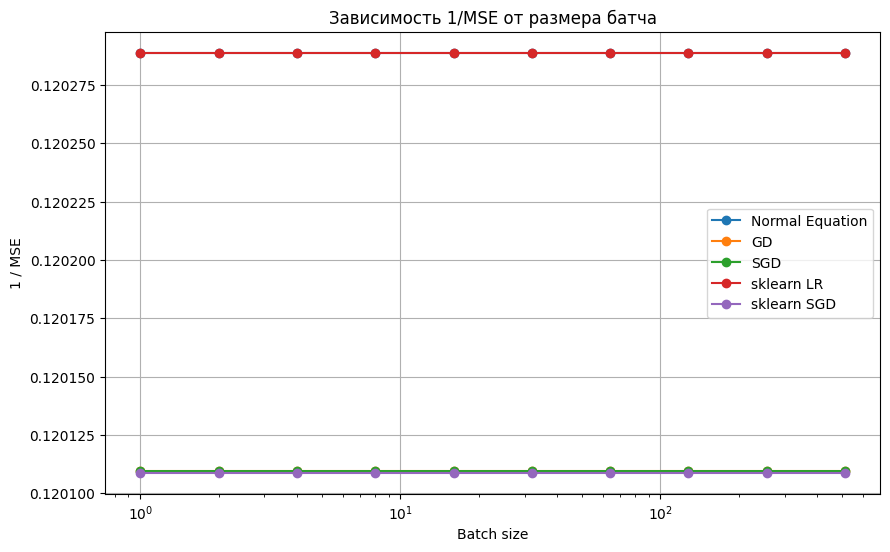


Таблица значений 1/MSE для Зависимость 1/MSE от размера батча:
            Normal Equation        GD       SGD  sklearn LR  sklearn SGD
Batch size                                                              
1                  0.120289  0.120109  0.120109    0.120289     0.120109
2                  0.120289  0.120109  0.120109    0.120289     0.120109
4                  0.120289  0.120109  0.120109    0.120289     0.120109
8                  0.120289  0.120109  0.120109    0.120289     0.120109
16                 0.120289  0.120109  0.120109    0.120289     0.120109
32                 0.120289  0.120109  0.120109    0.120289     0.120109
64                 0.120289  0.120109  0.120109    0.120289     0.120109
128                0.120289  0.120109  0.120109    0.120289     0.120109
256                0.120289  0.120109  0.120109    0.120289     0.120109
512                0.120289  0.120109  0.120109    0.120289     0.120109

Построение трехмерного графика зависимости числа эпох (до M

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline

# ---------- Загрузка данных ----------
df = pd.read_csv('data.csv')
X = df[['x']].values
y = df['y'].values

print(f"Данные загружены. X shape: {X.shape}, y shape: {y.shape}")

# ---------- Реализации методов ----------
def normal_equation(X, y, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def gradient_descent(X, y, lr=0.01, epochs=1000, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        w -= lr * 2 * X.T @ (X @ w - y)
    return w

def sgd(X, y, lr=0.01, epochs=100, batch_size=32, fit_intercept=True):
    if fit_intercept:
        X = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(X.shape[1])
    n = len(X)
    for _ in range(epochs):
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            w -= lr * 2 * Xb.T @ (Xb @ w - yb)
    return w

# ---------- Константы ----------
Xwb = np.hstack([np.ones((X.shape[0], 1)), X])
w_ne = normal_equation(X, y)
mse_ne = mean_squared_error(y, Xwb @ w_ne)
lr_sk = LinearRegression().fit(X, y)
mse_lr_sk = mean_squared_error(y, lr_sk.predict(X))

# ---------- Универсальная функция с возвратом NaN при расходимости ----------
def compute_mse(method, lr=None, epochs=None, batch_size=None):
    np.random.seed(42)
    try:
        if method == 'ne':
            return mse_ne
        elif method == 'gd':
            w = gradient_descent(X, y, lr=lr, epochs=epochs)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'sgd':
            w = sgd(X, y, lr=lr, epochs=epochs, batch_size=batch_size)
            if np.any(np.isnan(w)) or np.any(np.isinf(w)):
                return np.nan
            return mean_squared_error(y, Xwb @ w)
        elif method == 'lr_sk':
            return mse_lr_sk
        elif method == 'sgd_sk':
            sgd_sk = SGDRegressor(
                fit_intercept=True,
                max_iter=epochs,
                eta0=lr,
                learning_rate='constant',
                penalty=None,
                tol=None,
                random_state=42
            )
            sgd_sk.fit(X, y)
            y_pred = sgd_sk.predict(X)
            if np.any(np.isnan(y_pred)):
                return np.nan
            return mean_squared_error(y, y_pred)
        else:
            raise ValueError('Unknown method')
    except Exception:
        return np.nan

# ---------- Диапазоны гиперпараметров ----------
lr_range = np.logspace(-8, -1, 8)      # от 1e-8 до 0.1
epochs_range = [2, 20, 200, 2000, 20000]
batch_range = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

DEFAULT_EPOCHS = 1000
DEFAULT_BATCH = 32

methods = [
    ('ne', 'Normal Equation'),
    ('gd', 'GD'),
    ('sgd', 'SGD'),
    ('lr_sk', 'sklearn LR'),
    ('sgd_sk', 'sklearn SGD')
]

# ---------- Функция для построения графика и вывода таблицы для 1/MSE ----------
def plot_1over_mse(param_values, param_name, xlabel, title):
    plt.figure(figsize=(10, 6))
    results = {}
    for method, label in methods:
        inv_mses = []
        for val in param_values:
            if param_name == 'lr':
                mse = compute_mse(method, lr=val, epochs=DEFAULT_EPOCHS, batch_size=DEFAULT_BATCH)
            elif param_name == 'epochs':
                mse = compute_mse(method, lr=best_lr, epochs=val, batch_size=DEFAULT_BATCH)
            elif param_name == 'batch':
                mse = compute_mse(method, lr=best_lr, epochs=DEFAULT_EPOCHS, batch_size=val)
            if np.isnan(mse) or mse == 0:
                inv = np.nan
            else:
                inv = 1.0 / mse
            inv_mses.append(inv)
        results[label] = inv_mses
        plt.semilogx(param_values, inv_mses, marker='o', label=label)
    plt.xlabel(xlabel)
    plt.ylabel('1 / MSE')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    df_table = pd.DataFrame(results, index=param_values)
    df_table.index.name = xlabel
    print(f"\nТаблица значений 1/MSE для {title}:")
    print(df_table.round(6).to_string(na_rep='-'))
    return df_table

# ---------- Определяем best_lr по первому графику ----------
print("\n" + "="*60)
print("ГРАФИК 1 (MSE): Зависимость MSE от learning rate")
table_lr = plot_1over_mse(lr_range, 'lr', 'Learning rate', 'Зависимость 1/MSE от learning rate (для определения best_lr)')
# Используем те же данные, но для выбора best_lr нужны MSE, поэтому пересчитаем MSE отдельно
mse_values = []
for lr in lr_range:
    mse_values.append(compute_mse('gd', lr=lr, epochs=DEFAULT_EPOCHS, batch_size=DEFAULT_BATCH))
gd_mses = np.array(mse_values)
valid_lr = lr_range[~np.isnan(gd_mses)]
if len(valid_lr) > 0:
    best_lr = valid_lr[0]
    print(f"\nВыбран learning rate = {best_lr:.2e} (наименьший работающий для GD).")
else:
    best_lr = 1e-8
    print("\nGD не сошелся ни при одном learning rate, используем 1e-8.")

# ---------- Графики 1/MSE ----------
print("\n" + "="*60)
print("ГРАФИК 2: Зависимость 1/MSE от learning rate (все методы)")
plot_1over_mse(lr_range, 'lr', 'Learning rate', 'Зависимость 1/MSE от learning rate')

print("\n" + "="*60)
print("ГРАФИК 3: Зависимость 1/MSE от количества эпох")
plot_1over_mse(epochs_range, 'epochs', 'Epochs', 'Зависимость 1/MSE от количества эпох')

print("\n" + "="*60)
print("ГРАФИК 4: Зависимость 1/MSE от размера батча")
plot_1over_mse(batch_range, 'batch', 'Batch size', 'Зависимость 1/MSE от размера батча')

# ---------- Трехмерный график: количество эпох до достижения MSE < 15 для SGD ----------
print("\n" + "="*60)
print("Построение трехмерного графика зависимости числа эпох (до MSE<15) от lr и batch_size для SGD")

threshold = 15
max_epochs = 20000
# Создадим сетку эпох для поиска (логарифмическая шкала)
epochs_search = np.unique(np.logspace(0, np.log10(max_epochs), 30).astype(int))
epochs_search = epochs_search[epochs_search > 0]

# Матрица результатов
Z = np.full((len(lr_range), len(batch_range)), np.nan)

for i, lr in enumerate(lr_range):
    for j, bs in enumerate(batch_range):
        # Ищем минимальное число эпох, при котором MSE < threshold
        found = False
        for e in epochs_search:
            mse = compute_mse('sgd', lr=lr, epochs=e, batch_size=bs)
            if not np.isnan(mse) and mse < threshold:
                Z[i, j] = e
                found = True
                break
        if not found:
            Z[i, j] = np.nan  # не достигнуто за max_epochs

# Построение поверхности
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

X_grid, Y_grid = np.meshgrid(lr_range, batch_range, indexing='ij')
# Убираем NaN для построения (можно заменить на max_epochs, но лучше маскировать)
mask = ~np.isnan(Z)
ax.scatter(X_grid[mask], Y_grid[mask], Z[mask], c=Z[mask], cmap='viridis', s=50)

ax.set_xlabel('Learning rate')
ax.set_ylabel('Batch size')
ax.set_zlabel('Epochs to MSE < 15')
ax.set_title('Количество эпох до достижения MSE<15 (SGD)')
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()

# Таблица результатов
df_3d = pd.DataFrame(Z, index=lr_range, columns=batch_range)
df_3d.index.name = 'lr'
df_3d.columns.name = 'batch_size'
print("\nТаблица количества эпох до MSE<15 (NaN — не достигнуто за 20000):")
print(df_3d.round(1).to_string(na_rep='-'))